<div style="text-align:center">

# **UNIVERSIDAD INTERNACIONAL DE LA RIOJA - COLOMBIA**
## Especializacion en Inteligencia Artificial
### Asignatura: Aprendizaje Automatico
#### *Actividad 2 — Modelos Supervisados Avanzados y Aprendizaje No Supervisado*

</div>

---

**Presentado por:** Omar Javier Daza Leguizamon

**Fecha:** 13 de septiembre de 2026

---

## Objetivos
Aplicar los conocimientos adquiridos en los temas de árboles y random forest para un problema de regresión y uno de clasificación: predecir el precio de venta y el rango de precio del inmueble.

**Dataset:** Ames Housing (De Cock, 2011), publicado en Kaggle como *USA Housing Dataset* (`housing_train.csv`)

## Estructura del notebook

| Numeral | Contenido | Criterio de la rúbrica |
|---|---|---|
| 0 | Preparación y reconocimiento de los datos | — |
| 1 | Análisis descriptivo de los datos | 1 |
| 2 | Tratamiento de valores faltantes | 2 |
| 3 | Problema de regresión | 3 |
| 4 | Problema de clasificación | 4 |
| 5 | Agrupamiento para segmentación | 5 |
| 6 | Detección de anomalías | 6 |
| 7 | Aprendizaje por refuerzo | 7 |
| 8 | Comentarios sobre los resultados | 8 |

**Nota:** Todo el notebook está diseñado para ejecutarse de principio a fin con *Restart & Run All*. La semilla global es `RANDOM_STATE = 42`.

<!-- ---
## 0. Preparación previa a los análisis de datos
--- -->

---
## 0. Preparación y reconocimiento de los datos
---

### 0.1 Librerias, semilla, directorio.

In [55]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RUTA_DATOS = Path("data")
RUTA_FIGURAS = Path("figuras")
RUTA_SALIDAS = Path("salidas")
for ruta in (RUTA_FIGURAS, RUTA_SALIDAS):
    ruta.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.3


### 0.2 Lectura con control de valores nulos

El lector por defecto de pandas trata la cadena `"None"` como valor nulo, sin embaro en el dataset `None` es una categoría válida de la variable `MasVnrType`. Al leerla con la configuración por defecto se obtienen 872 faltantes en esa columna en lugar de los 8 reales, y el diagnóstico de faltantes no reflejaría la realidad de los datos.

Para hacer la lectura correcta se desactiva la lista por defecto y declara únicamente `NA` (la codificación usada por el dataset original) como valor ausente. Con esta configuración las cifras reproducen las de la Figura 4 del enunciado en el documento con las instrucciones de la actividad 2.

In [56]:
NA_VALUES = ["NA", ""]  # codificación real de ausencia en el dataset de Ames

df = pd.read_csv(RUTA_DATOS / "housing_train.csv", 
                 keep_default_na=False, na_values=NA_VALUES)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 0.3 Verificación de integridad

Antes de continuar con los análisis de los datos se confirma que el archivo es el esperado: número de registros, unicidad del identificador, presencia de la variable objetivo y ausencia de duplicados.

In [57]:
# Controles de integridad
print("Registros            :", len(df))
print("Columnas             :", df.shape[1])
print("Id único             :", df["Id"].is_unique, "| rango:", df["Id"].min(), "-", df["Id"].max())
print("Filas duplicadas     :", df.drop(columns="Id").duplicated().sum())
print("'SalePrice' presente :", "SalePrice" in df.columns)
print("Años de venta        :", df["YrSold"].min(), "-", df["YrSold"].max())

Registros            : 1460
Columnas             : 81
Id único             : True | rango: 1 - 1460
Filas duplicadas     : 0
'SalePrice' presente : True
Años de venta        : 2006 - 2010


### 0.4 Aclaracón sobre el dataset `housing_test.csv`

El archivo `housing_test.csv` (contiene 1.459 registros, Id 1461–2919) no contiene la columna `SalePrice`. Se entiende como el conjunto de evaluación ciega de la competencia de Kaggle. Por lo tanto, con este dataset no se puede calcular RMSE, matrices de confusión ni exactitud, que son las métricas exigidas en el documento con las instrucciones de la actividad. Toda la evaluación de esta actividad se realiza sobre una partición interna de `housing_train.csv`.

In [58]:
# Comprobación de la naturaleza del conjunto de test
df_test_kaggle = pd.read_csv(RUTA_DATOS / "housing_test.csv",
                             keep_default_na=False, na_values=NA_VALUES)
print("housing_test.csv     :", df_test_kaggle.shape)
print("'SalePrice' presente :", "SalePrice" in df_test_kaggle.columns)
print("Columnas ausentes    :", sorted(set(df.columns) - set(df_test_kaggle.columns)))

housing_test.csv     : (1459, 80)
'SalePrice' presente : False
Columnas ausentes    : ['SalePrice']


---
## 1. Análisis descriptivo de los datos (Criterio 1)
---

In [59]:
# Tipología de las variables
COL_ID = "Id"
COL_OBJETIVO = "SalePrice"

vars_numericas = [c for c in df.select_dtypes(include=[np.number]).columns if c != COL_ID]
vars_categoricas = [c for c in df.columns if c not in vars_numericas + [COL_ID]]

print(f"Variables numéricas   : {len(vars_numericas)} (incluye la objetivo '{COL_OBJETIVO}')")
print(f"Variables categóricas : {len(vars_categoricas)}")
print(f"Identificador         : {COL_ID} (se excluye de todo modelado)")

df.info(verbose=False)

Variables numéricas   : 37 (incluye la objetivo 'SalePrice')
Variables categóricas : 43
Identificador         : Id (se excluye de todo modelado)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), str(43)
memory usage: 924.0 KB


### 1.1 Estadísticos descriptivos de las variables numéricas

In [60]:
# Descriptivos de las variables numéricas
desc = df[vars_numericas].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
desc["faltantes"] = df[vars_numericas].isna().sum()
desc["pct_ceros"] = (df[vars_numericas] == 0).mean().mul(100).round(1)
desc["asimetria"] = df[vars_numericas].skew().round(2)
desc = desc.round(2)
desc.to_csv(RUTA_SALIDAS / "1_descriptivos_numericas.csv")
desc

,count,mean,std,min,25%,50%,75%,max,faltantes,pct_ceros,asimetria
MSSubClass,1460.0,56.90,42.30,20.0,20.00,50.0,70.00,190.0,0,0.0,1.41
LotFrontage,1201.0,70.05,24.28,21.0,59.00,69.0,80.00,313.0,259,0.0,2.16
LotArea,1460.0,10516.83,9981.26,1300.0,7553.50,9478.5,11601.50,215245.0,0,0.0,12.21
OverallQual,1460.0,6.10,1.38,1.0,5.00,6.0,7.00,10.0,0,0.0,0.22
OverallCond,1460.0,5.58,1.11,1.0,5.00,5.0,6.00,9.0,0,0.0,0.69
YearBuilt,1460.0,1971.27,30.20,1872.0,1954.00,1973.0,2000.00,2010.0,0,0.0,-0.61
YearRemodAdd,1460.0,1984.87,20.65,1950.0,1967.00,1994.0,2004.00,2010.0,0,0.0,-0.50
MasVnrArea,1452.0,103.69,181.07,0.0,0.00,0.0,166.00,1600.0,8,59.0,2.67
BsmtFinSF1,1460.0,443.64,456.10,0.0,0.00,383.5,712.25,5644.0,0,32.0,1.69
BsmtFinSF2,1460.0,46.55,161.32,0.0,0.00,0.0,0.00,1474.0,0,88.6,4.26


Estadísticas para la variable objetivo: `SalePrice`:

Mínimo   :     34,900
1er cuartil:  129,975
Mediana  :    163,000
Media    :    180,921
3er cuartil:  214,000
Máximo   :    755,000

Asimetría en escala original    : 1.883
Asimetría tras log-transformación: 0.121


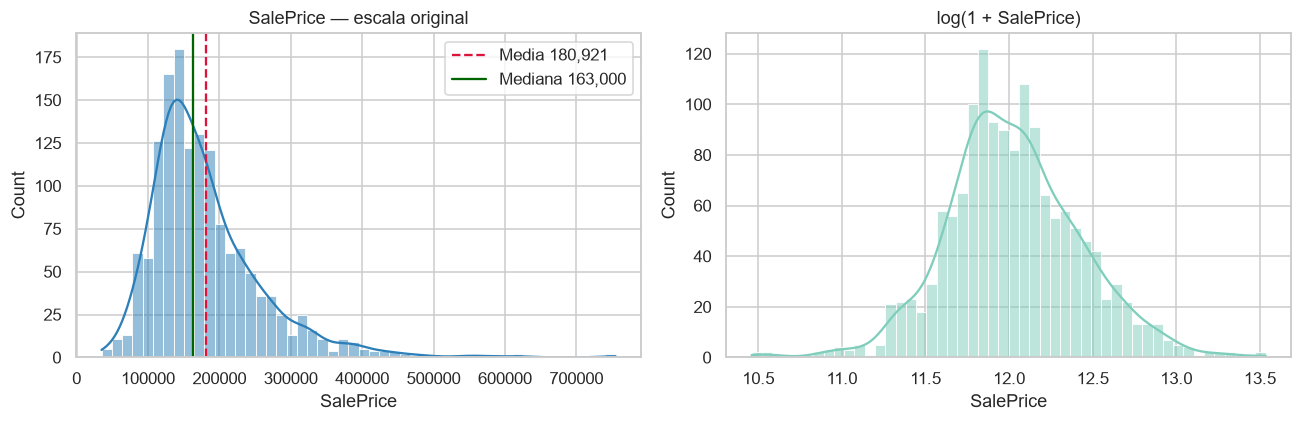

In [61]:
# Distribución de la variable objetivo
precio = df[COL_OBJETIVO]
print(f"Mínimo   : {precio.min():>10,.0f}")
print(f"1er cuartil: {precio.quantile(.25):>8,.0f}")
print(f"Mediana  : {precio.median():>10,.0f}")
print(f"Media    : {precio.mean():>10,.0f}")
print(f"3er cuartil: {precio.quantile(.75):>8,.0f}")
print(f"Máximo   : {precio.max():>10,.0f}")
print(f"\nAsimetría en escala original    : {precio.skew():.3f}")
print(f"Asimetría tras log-transformación: {np.log1p(precio).skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(precio, bins=50, kde=True, ax=axes[0], color="#2c7fb8")
axes[0].axvline(precio.mean(), color="crimson", ls="--", label=f"Media {precio.mean():,.0f}")
axes[0].axvline(precio.median(), color="darkgreen", ls="-", label=f"Mediana {precio.median():,.0f}")
axes[0].set_title("SalePrice — escala original"); axes[0].legend()
sns.histplot(np.log1p(precio), bins=50, kde=True, ax=axes[1], color="#7fcdbb")
axes[1].set_title("log(1 + SalePrice)")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "1_distribucion_saleprice.png", bbox_inches="tight")
plt.show()

### 1.2 Categorías y frecuencias de las variables categóricas

In [62]:
# Resumen de las variables categóricas
filas = []
for col in vars_categoricas:
    conteo = df[col].value_counts(dropna=False)
    filas.append({
        "variable": col,
        "n_categorias": df[col].nunique(dropna=True),
        "mas_frecuente": conteo.index[0],
        "frecuencia": int(conteo.iloc[0]),
        "pct_dominante": round(100 * conteo.iloc[0] / len(df), 1),
        "faltantes": int(df[col].isna().sum()),
    })

resumen_cat = pd.DataFrame(filas).sort_values("n_categorias", ascending=False).reset_index(drop=True)
resumen_cat.to_csv(RUTA_SALIDAS / "1_resumen_categoricas.csv", index=False)
resumen_cat

,variable,n_categorias,mas_frecuente,frecuencia,pct_dominante,faltantes
0,Neighborhood,25,NAmes,225,15.4,0
1,Exterior2nd,16,VinylSd,504,34.5,0
2,Exterior1st,15,VinylSd,515,35.3,0
3,Condition1,9,Norm,1260,86.3,0
4,SaleType,9,WD,1267,86.8,0
5,HouseStyle,8,1Story,726,49.7,0
6,RoofMatl,8,CompShg,1434,98.2,0
7,Condition2,8,Norm,1445,99.0,0
8,Functional,7,Typ,1360,93.2,0
9,BsmtFinType2,6,Unf,1256,86.0,38


In [63]:
# Categorías y frecuencias de todas las variables categóricas
for col in vars_categoricas:
    tabla = df[col].value_counts(dropna=False).rename("frecuencia").to_frame()
    tabla["pct"] = (100 * tabla["frecuencia"] / len(df)).round(1)
    print(f"--- {col} ({df[col].nunique(dropna=True)} categorías) ---")
    print(tabla.to_string(), "\n")

with open(RUTA_SALIDAS / "1_frecuencias_categoricas.txt", "w", encoding="utf-8") as f:
    for col in vars_categoricas:
        f.write(f"--- {col} ---\n{df[col].value_counts(dropna=False).to_string()}\n\n")

--- MSZoning (5 categorías) ---
          frecuencia   pct
MSZoning                  
RL              1151  78.8
RM               218  14.9
FV                65   4.5
RH                16   1.1
C (all)           10   0.7 

--- Street (2 categorías) ---
        frecuencia   pct
Street                  
Pave          1454  99.6
Grvl             6   0.4 

--- Alley (2 categorías) ---
       frecuencia   pct
Alley                  
NaN          1369  93.8
Grvl           50   3.4
Pave           41   2.8 

--- LotShape (4 categorías) ---
          frecuencia   pct
LotShape                  
Reg              925  63.4
IR1              484  33.2
IR2               41   2.8
IR3               10   0.7 

--- LandContour (4 categorías) ---
             frecuencia   pct
LandContour                  
Lvl                1311  89.8
Bnk                  63   4.3
HLS                  50   3.4
Low                  36   2.5 

--- Utilities (2 categorías) ---
           frecuencia   pct
Utilities           

### 1.3 Matriz de correlaciones

Se utiliza el coeficiente de **Pearson** para medir la asociación lineal entre variables numéricas continuas. La matriz completa tiene 37 variables.

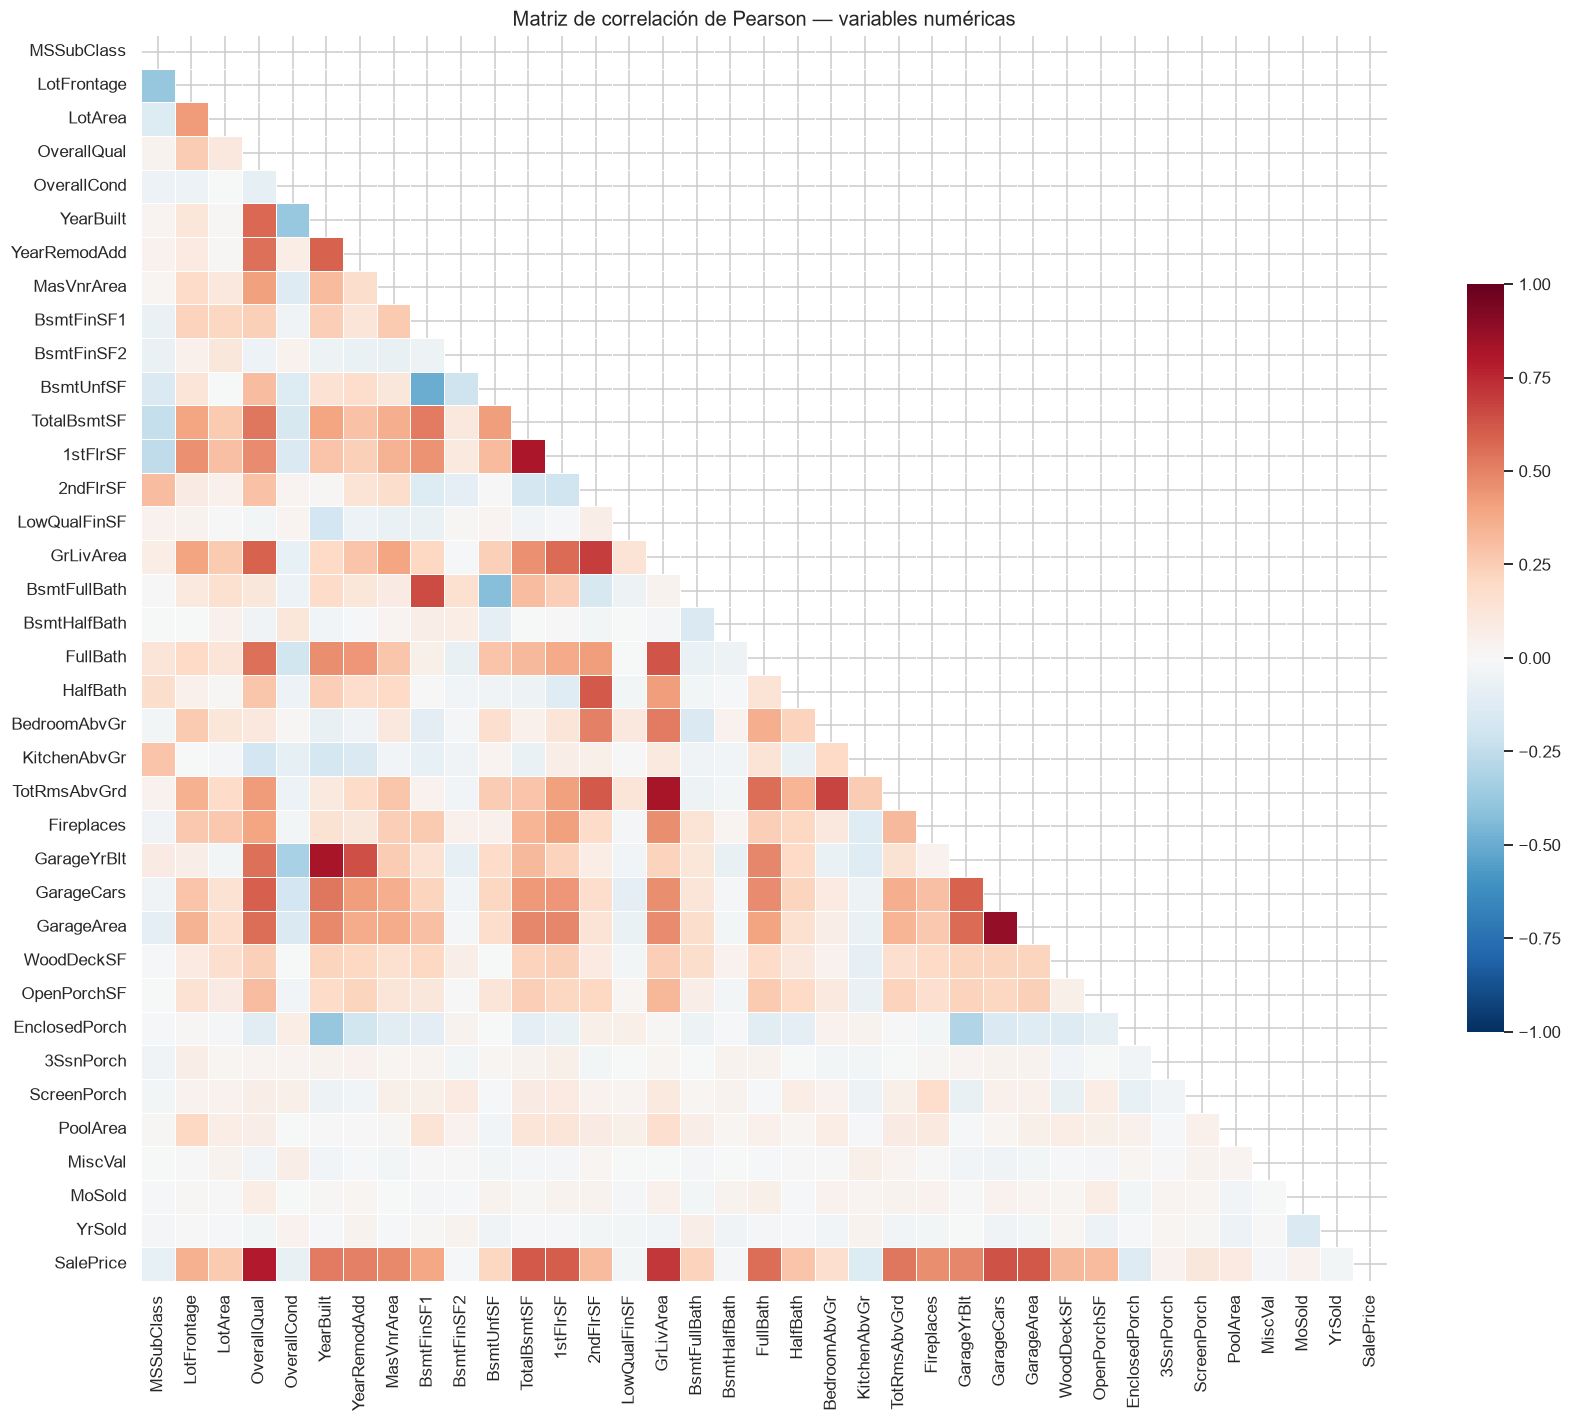

In [64]:
# Matriz de correlación de Pearson
corr = df[vars_numericas].corr(method="pearson")

mascara = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(16, 13))
sns.heatmap(corr, mask=mascara, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, cbar_kws={"shrink": .6})
plt.title("Matriz de correlación de Pearson — variables numéricas", fontsize=13)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "1_matriz_correlacion.png", bbox_inches="tight")
plt.show()

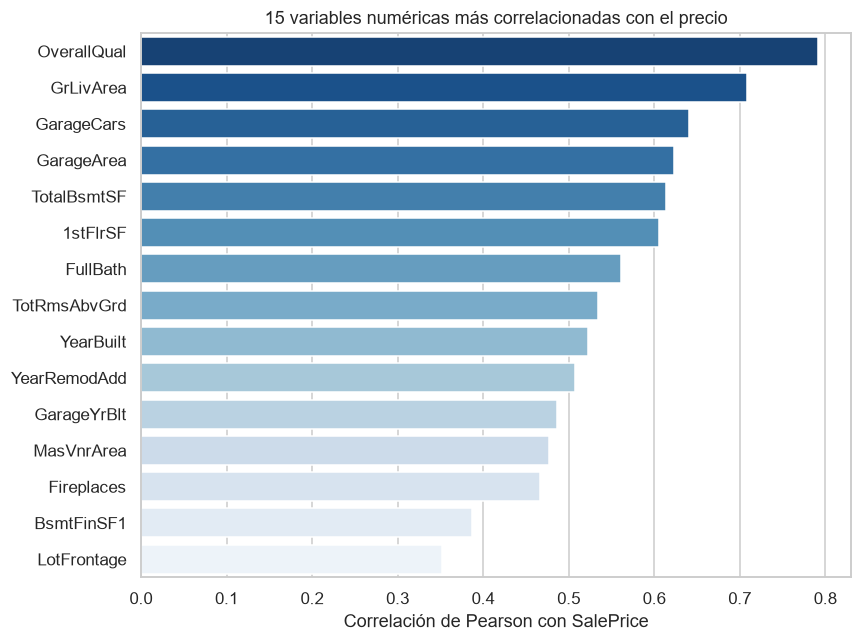

Mayores correlaciones positivas:
 OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507

Mayores correlaciones negativas:
 YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136


In [65]:
# Variables más correlacionadas con el precio de venta
corr_precio = corr[COL_OBJETIVO].drop(COL_OBJETIVO).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
top15 = corr_precio.head(15)
sns.barplot(x=top15.values, y=top15.index, hue=top15.index, palette="Blues_r", legend=False)
plt.xlabel("Correlación de Pearson con SalePrice"); plt.ylabel("")
plt.title("15 variables numéricas más correlacionadas con el precio")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "1_correlacion_saleprice.png", bbox_inches="tight")
plt.show()

print("Mayores correlaciones positivas:\n", corr_precio.head(10).round(3).to_string())
print("\nMayores correlaciones negativas:\n", corr_precio.tail(5).round(3).to_string())

In [66]:
# Pares de variables muy correlacionadas entre sí
UMBRAL = 0.70
corr_pred = corr.drop(index=COL_OBJETIVO, columns=COL_OBJETIVO).abs()
pares = corr_pred.where(np.triu(np.ones(corr_pred.shape), k=1).astype(bool)).stack()
pares = pares[pares >= UMBRAL].sort_values(ascending=False)

print(f"Pares con correlación mayor o igual a {UMBRAL}:\n")
for (a, b), valor in pares.items():
    print(f"{a:<15} - {b:<15} r = {valor:.3f}   "
          f"(corr. con precio: {abs(corr_precio[a]):.2f} vs {abs(corr_precio[b]):.2f})")

Pares con correlación mayor o igual a 0.7:

GarageCars      - GarageArea      r = 0.882   (corr. con precio: 0.64 vs 0.62)
YearBuilt       - GarageYrBlt     r = 0.826   (corr. con precio: 0.52 vs 0.49)
GrLivArea       - TotRmsAbvGrd    r = 0.825   (corr. con precio: 0.71 vs 0.53)
TotalBsmtSF     - 1stFlrSF        r = 0.820   (corr. con precio: 0.61 vs 0.61)


---
## 2. Tratamiento de valores faltantes (Criterio 2)
---

### 2.1 Inventario de datos faltantes

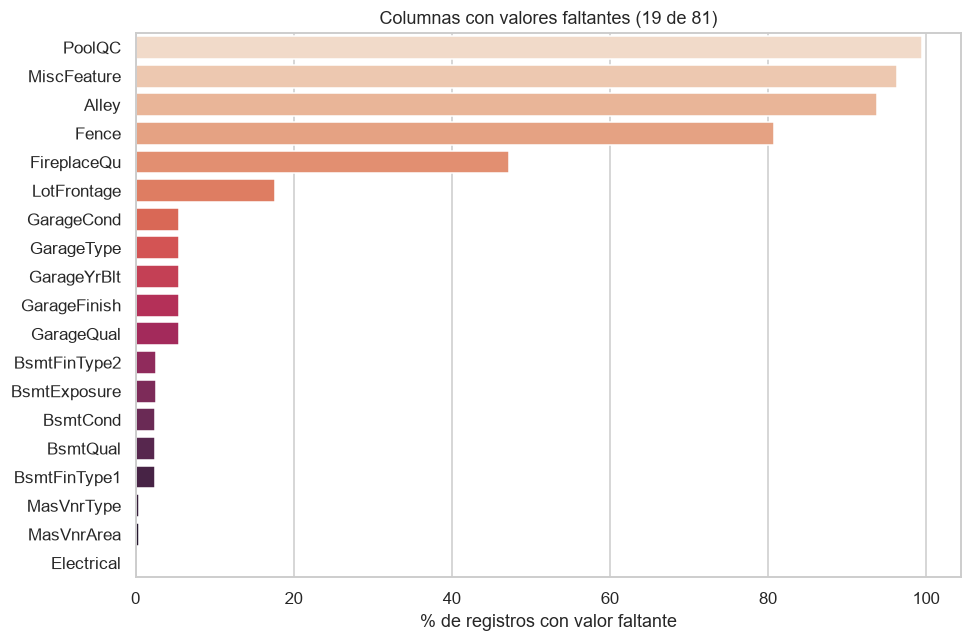

,faltantes,pct,tipo_variable
PoolQC,1453,99.5,categórica
MiscFeature,1406,96.3,categórica
Alley,1369,93.8,categórica
Fence,1179,80.8,categórica
FireplaceQu,690,47.3,categórica
LotFrontage,259,17.7,numérica
GarageCond,81,5.5,categórica
GarageType,81,5.5,categórica
GarageYrBlt,81,5.5,numérica
GarageFinish,81,5.5,categórica


In [67]:
# Inventario completo de valores faltantes
faltantes = df.isna().sum()
faltantes = faltantes[faltantes > 0].sort_values(ascending=False)
inventario = pd.DataFrame({
    "faltantes": faltantes,
    "pct": (100 * faltantes / len(df)).round(1),
    "tipo_variable": ["categórica" if v in vars_categoricas else "numérica" for v in faltantes.index],
})
inventario.to_csv(RUTA_SALIDAS / "2_inventario_faltantes.csv")

plt.figure(figsize=(9, 6))
sns.barplot(x=inventario["pct"], y=inventario.index, hue=inventario.index,
            palette="rocket_r", legend=False)
plt.xlabel("% de registros con valor faltante"); plt.ylabel("")
plt.title("Columnas con valores faltantes (19 de 81)")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "2_faltantes.png", bbox_inches="tight")
plt.show()

inventario

Para el llenado de valores faltantes, también llamado imputación, se distinguen dos tipos de ausencia. El **faltante real** es un dato que existe pero no se registró, como `LotFrontage`, ya que toda vivienda tiene fachada; procede imputarlo con un estadístico. El **faltante estructural** indica que la característica no existe en esa vivienda, como `BsmtQual` en una casa sin sótano; ahí el `NA` es información y debe convertirse en una categoría propia, porque imputar la moda inventaría un sótano inexistente.

La Figura 4 en el documento de las instrucciones de la actividad se muestran seis bloques de variables, pero el conjunto presenta 19 columnas con faltantes. Las cinco de mayor porcentaje (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`) no aparecen en esa figura y son todas estructurales.

### 2.2 Decisiones adoptadas para el llenado de datos faltantes

#### 2.2.1 Redoficación de los faltantes estructurales

In [68]:
# Variables categóricas cuyo NA significa "la vivienda no tiene esa característica".
ESTRUCTURALES = {
    "PoolQC": "SinPiscina",
    "MiscFeature": "SinCaracteristicaExtra",
    "Alley": "SinCallejon",
    "Fence": "SinCerca",
    "FireplaceQu": "SinChimenea",
    "BsmtQual": "SinSotano", "BsmtCond": "SinSotano", "BsmtExposure": "SinSotano",
    "BsmtFinType1": "SinSotano", "BsmtFinType2": "SinSotano",
    "GarageType": "SinGaraje", "GarageFinish": "SinGaraje",
    "GarageQual": "SinGaraje", "GarageCond": "SinGaraje",
}

df_limpio = df.copy()
for columna, etiqueta in ESTRUCTURALES.items():
    n = df_limpio[columna].isna().sum()
    df_limpio[columna] = df_limpio[columna].fillna(etiqueta)
    print(f"{columna:<15} {n:>5} NA  ->  categoría '{etiqueta}'")

# Coherencia: las viviendas sin sótano deben tener TotalBsmtSF = 0
sin_sotano = df_limpio["BsmtQual"] == "SinSotano"
print(f"\nComprobación — viviendas sin sótano: {sin_sotano.sum()}; "
      f"de ellas con TotalBsmtSF = 0: {(df_limpio.loc[sin_sotano, 'TotalBsmtSF'] == 0).sum()}")
sin_garaje = df_limpio["GarageType"] == "SinGaraje"
print(f"Comprobación — viviendas sin garaje: {sin_garaje.sum()}; "
      f"de ellas con GarageArea = 0: {(df_limpio.loc[sin_garaje, 'GarageArea'] == 0).sum()}")

# Comprobación de coherencia de los faltantes estructurales
chequeos = [("PoolQC", "PoolArea"), ("FireplaceQu", "Fireplaces"),
            ("BsmtQual", "TotalBsmtSF"), ("GarageType", "GarageArea")]
for cualitativa, cuantitativa in chequeos:
    sin_dato = df[cualitativa].isna()
    en_cero = (df.loc[sin_dato, cuantitativa] == 0).sum()
    print(f"{cualitativa:<12} {sin_dato.sum():>5} NA | con {cuantitativa} = 0: {en_cero}")

PoolQC           1453 NA  ->  categoría 'SinPiscina'
MiscFeature      1406 NA  ->  categoría 'SinCaracteristicaExtra'
Alley            1369 NA  ->  categoría 'SinCallejon'
Fence            1179 NA  ->  categoría 'SinCerca'
FireplaceQu       690 NA  ->  categoría 'SinChimenea'
BsmtQual           37 NA  ->  categoría 'SinSotano'
BsmtCond           37 NA  ->  categoría 'SinSotano'
BsmtExposure       38 NA  ->  categoría 'SinSotano'
BsmtFinType1       37 NA  ->  categoría 'SinSotano'
BsmtFinType2       38 NA  ->  categoría 'SinSotano'
GarageType         81 NA  ->  categoría 'SinGaraje'
GarageFinish       81 NA  ->  categoría 'SinGaraje'
GarageQual         81 NA  ->  categoría 'SinGaraje'
GarageCond         81 NA  ->  categoría 'SinGaraje'

Comprobación — viviendas sin sótano: 37; de ellas con TotalBsmtSF = 0: 37
Comprobación — viviendas sin garaje: 81; de ellas con GarageArea = 0: 81
PoolQC        1453 NA | con PoolArea = 0: 1453
FireplaceQu    690 NA | con Fireplaces = 0: 690
BsmtQual    

#### 2.2.2 Llenado directo de valores faltantes

In [69]:
# Imputaciones deterministas (no dependen de estadísticos de la muestra)
# GarageYrBlt: si no hay garaje, se usa el año de construcción de la vivienda.
n_garage_yr = df_limpio["GarageYrBlt"].isna().sum()
df_limpio["GarageYrBlt"] = df_limpio["GarageYrBlt"].fillna(df_limpio["YearBuilt"])
print(f"GarageYrBlt : {n_garage_yr} NA -> YearBuilt de la misma vivienda")

# MasVnrArea: la mediana y ambos cuartiles valen 0; la ausencia equivale a "sin revestimiento".
n_masvnr = df_limpio["MasVnrArea"].isna().sum()
df_limpio["MasVnrArea"] = df_limpio["MasVnrArea"].fillna(0)
print(f"MasVnrArea  : {n_masvnr} NA -> 0")

# MasVnrType: se alinea con MasVnrArea = 0, es decir la categoría 'None' ya existente.
n_masvnrt = df_limpio["MasVnrType"].isna().sum()
df_limpio["MasVnrType"] = df_limpio["MasVnrType"].fillna("None")
print(f"MasVnrType  : {n_masvnrt} NA -> 'None' (categoría existente, 864 casos)")

GarageYrBlt : 81 NA -> YearBuilt de la misma vivienda
MasVnrArea  : 8 NA -> 0
MasVnrType  : 8 NA -> 'None' (categoría existente, 864 casos)


#### 2.2.3 Llenado de valores faltantes al entrenar

`LotFrontage` (mediana) y `Electrical` (moda) quedan sin imputar aquí. Ambas requieren un estadístico calculado sobre los datos, y calcularlo antes de separar entrenamiento y prueba haría que el conjunto de prueba influyera en el entrenamiento. Se imputan en la sección 3.1, ajustando el estadístico solo con el conjunto de entrenamiento.

In [70]:
# Estado final de los faltantes
restantes = df_limpio.isna().sum()
restantes = restantes[restantes > 0]
print("Faltantes pendientes (se imputan dentro del pipeline, Sección 3.1):")
print(restantes.to_string() if len(restantes) else "ninguno")
print(f"\nTotal de celdas faltantes: antes {df.isna().sum().sum():,} -> ahora {df_limpio.isna().sum().sum():,}")

Faltantes pendientes (se imputan dentro del pipeline, Sección 3.1):
LotFrontage    259
Electrical       1

Total de celdas faltantes: antes 6,965 -> ahora 260


El documento con las instrucciones de la actividad define los grupos con dos redacciones: en el apartado *Descripción* usa 100.001–500.000 y ≥ 500.001, y en el apartado *Metodología* usa 101.000–500.000 y ≥ 501.000. La celda comprueba que ninguna vivienda cae en los intervalos donde ambas difieren, por lo que producen la misma partición. Se adopta la del apartado *Descripción*.

In [71]:
# Creación de la variable de clase y verificación de las dos redacciones
huecos = {
    "100.001 – 100.999": int(((precio > 100_000) & (precio < 101_000)).sum()),
    "500.001 – 500.999": int(((precio > 500_000) & (precio < 501_000)).sum()),
}
print("Registros en los intervalos donde difieren ambas definiciones:", huecos)

df_limpio["grupo"] = pd.cut(df_limpio[COL_OBJETIVO],
                            bins=[-np.inf, 100_000, 500_000, np.inf],
                            labels=["grupo1", "grupo2", "grupo3"])

distribucion = df_limpio["grupo"].value_counts().sort_index().to_frame("n")
distribucion["pct"] = (100 * distribucion["n"] / len(df_limpio)).round(2)
distribucion["esperados_en_test_20pct"] = (distribucion["n"] * 0.2).round(0).astype(int)
print()
distribucion

Registros en los intervalos donde difieren ambas definiciones: {'100.001 – 100.999': 0, '500.001 – 500.999': 0}



,n,pct,esperados_en_test_20pct
grupo,,,
grupo1,123,8.42,25
grupo2,1328,90.96,266
grupo3,9,0.62,2


---
## 3. Problema de regresión (Criterio 3)
---

Se aplican árbol de decisión, árbol podado, random forest, gradient boosting y red neuronal al problema de predecir `SalePrice`, y se comparan mediante el RMSE sobre el conjunto de prueba.

### 3.1 Partición de los datos y preprocesamiento

Se define una sola partición 80/20, que se reutiliza en las secciones 3 y 4 para que las comparaciones entre modelos sean válidas. La estratificación se hace por la variable `grupo`: con solo 9 viviendas en el grupo3, una partición aleatoria podría dejar cero casos de esa clase en prueba.

In [72]:
# Partición estratificada única
from sklearn.model_selection import train_test_split

X = df_limpio.drop(columns=[COL_ID, COL_OBJETIVO, "grupo"])
y_reg = df_limpio[COL_OBJETIVO]     # objetivo de regresión
y_clf = df_limpio["grupo"]          # objetivo de clasificación

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y_reg, y_clf, test_size=0.20, random_state=RANDOM_STATE, stratify=y_clf)

print(f"Entrenamiento: {X_train.shape[0]:>5} registros")
print(f"Prueba       : {X_test.shape[0]:>5} registros")
print(f"Predictores  : {X.shape[1]}\n")

comp = pd.DataFrame({"entrenamiento": g_train.value_counts().sort_index(),
                     "prueba": g_test.value_counts().sort_index()})
comp.loc["TOTAL"] = comp.sum()
comp

Entrenamiento:  1168 registros
Prueba       :   292 registros
Predictores  : 79



,entrenamiento,prueba
grupo,,
grupo1,98,25
grupo2,1063,265
grupo3,7,2
TOTAL,1168,292


El conjunto de prueba queda con 25 casos del grupo1, 265 del grupo2 y 2 del grupo3, en total 292 registros. Coincide con la distribución de las matrices de confusión de las Figuras 6 y 7 presentadas en el documento con las instrucciones de la actividad, lo que confirma que las cifras de referencia se obtuvieron con una partición 80/20 de `housing_train.csv`.

Se definen dos preprocesadores porque los algoritmos tienen requisitos distintos. Los modelos de árbol no necesitan estandarización y admiten codificación ordinal. SVM y la red neuronal miden distancias, de modo que requieren estandarizar las variables numéricas y codificar las categóricas en *one-hot*. Ambos se ajustan solo con el conjunto de entrenamiento.

In [73]:
# Definición de los preprocesadores
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

col_num = X.select_dtypes(include=[np.number]).columns.tolist()
col_cat = [c for c in X.columns if c not in col_num]

# Para árboles, random forest y boosting
prep_arboles = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), col_num),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("codificar", OrdinalEncoder(handle_unknown="use_encoded_value",
                                                   unknown_value=-1))]), col_cat),
])

# Para SVM, red neuronal y agrupamiento
prep_escalado = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")),
                      ("escalar", StandardScaler())]), col_num),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("codificar", OneHotEncoder(handle_unknown="ignore",
                                                  sparse_output=False))]), col_cat),
])

prep_arboles.fit(X_train)
prep_escalado.fit(X_train)

Xtr_arb, Xte_arb = prep_arboles.transform(X_train), prep_arboles.transform(X_test)
Xtr_esc, Xte_esc = prep_escalado.transform(X_train), prep_escalado.transform(X_test)
nombres_arb = [n.split("__")[-1] for n in prep_arboles.get_feature_names_out()]

print(f"Predictores numéricos: {len(col_num)} | categóricos: {len(col_cat)}")
print(f"Matriz para árboles: {Xtr_arb.shape} | matriz escalada: {Xtr_esc.shape}")
print(f"Valores faltantes restantes: {np.isnan(Xtr_arb).sum() + np.isnan(Xte_arb).sum()}")

Predictores numéricos: 36 | categóricos: 43
Matriz para árboles: (1168, 79) | matriz escalada: (1168, 296)
Valores faltantes restantes: 0


In [74]:
# Función común de evaluación para regresión
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

resultados_regresion = []

def evaluar_regresion(nombre, y_verdadero, y_predicho, notas=""):
    fila = {"modelo": nombre,
            "RMSE": root_mean_squared_error(y_verdadero, y_predicho),
            "MAE": mean_absolute_error(y_verdadero, y_predicho),
            "R2": r2_score(y_verdadero, y_predicho),
            "notas": notas}
    resultados_regresion.append(fila)
    print(f"{nombre:<22} RMSE = {fila['RMSE']:>11,.1f} | MAE = {fila['MAE']:>10,.1f} | R² = {fila['R2']:.4f}")
    return fila

print(f"Precio medio en el conjunto de prueba: {y_test.mean():,.0f} USD")

Precio medio en el conjunto de prueba: 181,978 USD


### 3.2 Árbol de descisión y efecto de la poda

#### 3.2.1 Árbol de decisión sin podar

Un árbol sin restricciones crece hasta separar casi por completo los datos de entrenamiento. El número de hojas frente al número de registros indica el grado de sobreajuste.

In [75]:
# Árbol de decisión de regresión sin podar
from sklearn.tree import DecisionTreeRegressor, plot_tree

arbol = DecisionTreeRegressor(random_state=RANDOM_STATE)
arbol.fit(Xtr_arb, y_train)

print(f"Profundidad: {arbol.get_depth()} | hojas: {arbol.get_n_leaves()} "
      f"(sobre {len(X_train)} registros de entrenamiento)")
print(f"RMSE en entrenamiento: {root_mean_squared_error(y_train, arbol.predict(Xtr_arb)):,.1f}")
evaluar_regresion("Árbol sin podar", y_test, arbol.predict(Xte_arb),
                  f"profundidad {arbol.get_depth()}, {arbol.get_n_leaves()} hojas")

Profundidad: 25 | hojas: 1133 (sobre 1168 registros de entrenamiento)
RMSE en entrenamiento: 0.0
Árbol sin podar        RMSE =    38,816.5 | MAE =   26,432.4 | R² = 0.7678


{'modelo': 'Árbol sin podar',
 'RMSE': 38816.45916634242,
 'MAE': 26432.424657534248,
 'R2': 0.7678212143587515,
 'notas': 'profundidad 25, 1133 hojas'}

### 3.2.2 Árbol podado

La poda se hace por complejidad de coste, que penaliza el número de hojas con el parámetro `ccp_alpha`. Ese valor se elige por validación cruzada de 5 particiones dentro del conjunto de entrenamiento, sin usar el conjunto de prueba.

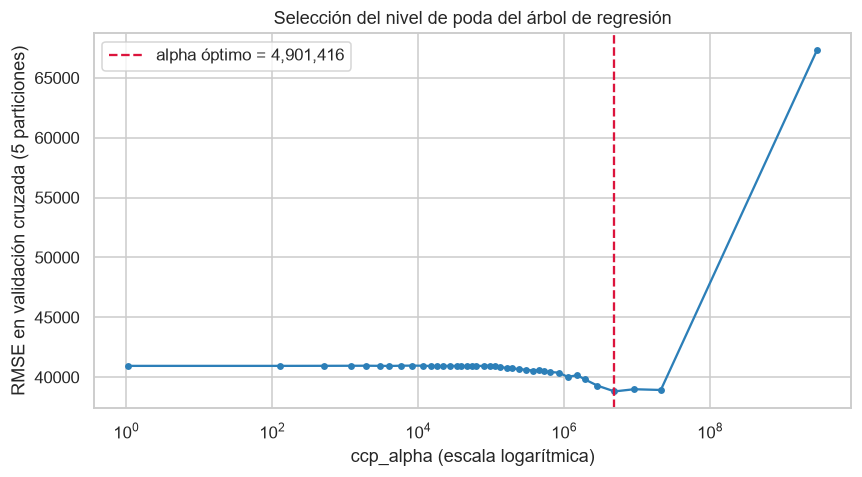

Hojas: 1133 -> 70 tras la poda
Árbol podado           RMSE =    37,226.8 | MAE =   25,804.7 | R² = 0.7864


{'modelo': 'Árbol podado',
 'RMSE': 37226.77676647446,
 'MAE': 25804.736533056566,
 'R2': 0.7864490182755531,
 'notas': 'ccp_alpha 4,901,416, 70 hojas'}

In [76]:
# Selección del nivel de poda por validación cruzada
from sklearn.model_selection import KFold, cross_val_score

camino = arbol.cost_complexity_pruning_path(Xtr_arb, y_train)
alphas = np.unique(camino.ccp_alphas)
alphas = alphas[alphas > 0]
alphas = alphas[np.linspace(0, len(alphas) - 1, 40).astype(int)]  # 40 valores representativos

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rmse_cv = [
    -cross_val_score(DecisionTreeRegressor(random_state=RANDOM_STATE, ccp_alpha=a),
                     Xtr_arb, y_train, cv=kf,
                     scoring="neg_root_mean_squared_error").mean()
    for a in alphas
]
alpha_optimo = alphas[int(np.argmin(rmse_cv))]

plt.figure(figsize=(8, 4.5))
plt.plot(alphas, rmse_cv, marker="o", ms=3.5, color="#2c7fb8")
plt.axvline(alpha_optimo, color="crimson", ls="--",
            label=f"alpha óptimo = {alpha_optimo:,.0f}")
plt.xscale("log"); plt.xlabel("ccp_alpha (escala logarítmica)")
plt.ylabel("RMSE en validación cruzada (5 particiones)")
plt.title("Selección del nivel de poda del árbol de regresión")
plt.legend(); plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "3_seleccion_poda.png", bbox_inches="tight")
plt.show()

arbol_podado = DecisionTreeRegressor(random_state=RANDOM_STATE, ccp_alpha=alpha_optimo)
arbol_podado.fit(Xtr_arb, y_train)
print(f"Hojas: {arbol.get_n_leaves()} -> {arbol_podado.get_n_leaves()} tras la poda")
evaluar_regresion("Árbol podado", y_test, arbol_podado.predict(Xte_arb),
                  f"ccp_alpha {alpha_optimo:,.0f}, {arbol_podado.get_n_leaves()} hojas")

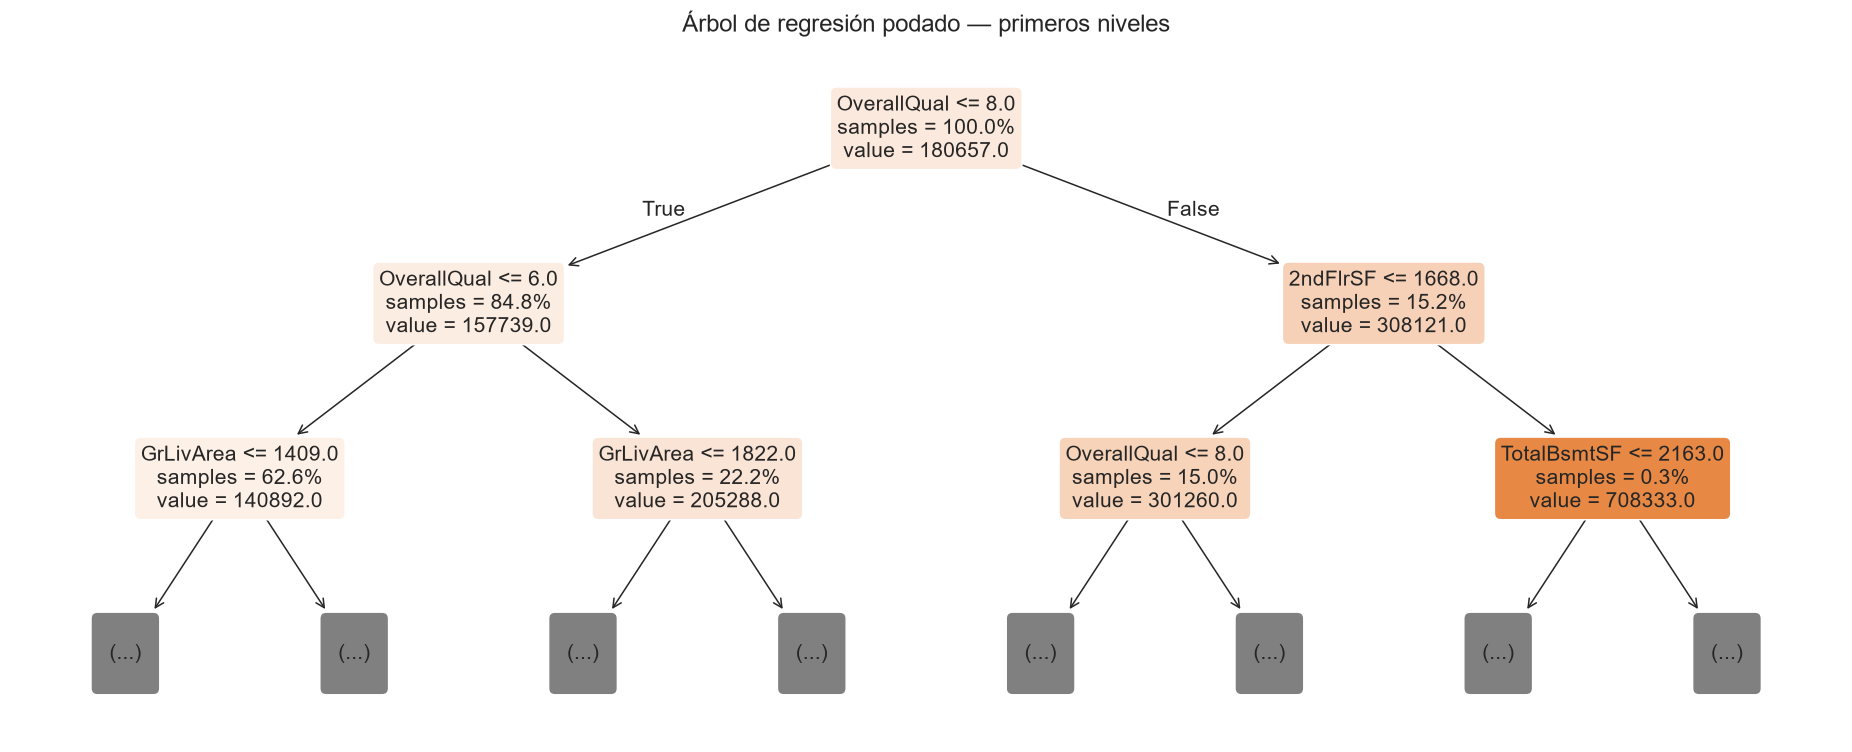

In [77]:
# Estructura del árbol podado (primeros tres niveles)
plt.figure(figsize=(17, 7))
plot_tree(arbol_podado, max_depth=2, feature_names=nombres_arb, filled=True,
          rounded=True, fontsize=14, impurity=False,
          precision=0, proportion=True)
plt.title("Árbol de regresión podado — primeros niveles", fontsize=16)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "3_arbol_podado.png", bbox_inches="tight")
plt.show()

### 3.3 Random forest gradient boosting

#### 3.3.1 Random forest

Random forest entrena cada árbol sobre una muestra *bootstrap* distinta y, en cada división, considera solo un subconjunto de predictores. Al promediar árboles poco correlacionados entre sí, reduce la varianza del conjunto.

In [78]:
# Random Forest de regresión
from sklearn.ensemble import RandomForestRegressor

bosque = RandomForestRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)
bosque.fit(Xtr_arb, y_train)

evaluar_regresion("Random Forest", y_test, bosque.predict(Xte_arb), "500 árboles, mtry por defecto")

Random Forest          RMSE =    29,615.4 | MAE =   18,807.7 | R² = 0.8648


{'modelo': 'Random Forest',
 'RMSE': 29615.417495258647,
 'MAE': 18807.700602739726,
 'R2': 0.8648467725738364,
 'notas': '500 árboles, mtry por defecto'}

#### 3.3.2 Gradient boosting con XGBoost

A diferencia del random forest, que promedia árboles independientes, el boosting los construye de forma secuencial: cada árbol se ajusta sobre los residuos que dejó el conjunto anterior. Reduce el sesgo con más agresividad, y el riesgo de sobreajuste se controla con la tasa de aprendizaje, la profundidad y la detención temprana.

In [79]:
# XGBoost para regresión
import xgboost as xgb

modelo_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="rmse",
    early_stopping_rounds=50,
)
modelo_xgb.fit(Xtr_arb, y_train, eval_set=[(Xte_arb, y_test)], verbose=False)

print(f"Árboles construidos: {modelo_xgb.best_iteration + 1} de 1000 "
      f"(detención temprana a las 50 rondas sin mejora)")
evaluar_regresion("XGBoost", y_test, modelo_xgb.predict(Xte_arb),
                  f"lr 0.05, profundidad 4, {modelo_xgb.best_iteration + 1} árboles")

Árboles construidos: 339 de 1000 (detención temprana a las 50 rondas sin mejora)
XGBoost                RMSE =    24,519.7 | MAE =   15,461.4 | R² = 0.9074


{'modelo': 'XGBoost',
 'RMSE': 24519.65234375,
 'MAE': 15461.3525390625,
 'R2': 0.907355546951294,
 'notas': 'lr 0.05, profundidad 4, 339 árboles'}

### 3.3 Red neuronal multicapa (MLP)

**Arquitectura:** dos capas ocultas densas de 128 y 64 neuronas con activación ReLU, una capa de *dropout* al 20 % como regularización y una neurona de salida lineal, apropiada para regresión.

**Entrenamiento:** optimizador Adam con tasa de aprendizaje 0,001 y error cuadrático medio como función de pérdida, con detención temprana sobre un 20 % del entrenamiento reservado para validación. El aprendizaje ocurre por retropropagación: tras cada lote se calcula el error, se propaga hacia atrás por la red mediante la regla de la cadena y se ajustan los pesos en dirección opuesta al gradiente.

**Variable objetivo:** se transforma con logaritmo y se estandariza. Sin estandarizar, unas pocas predicciones extremas se amplifican al deshacer la exponencial y el RMSE en dólares se dispara. Las predicciones se devuelven a dólares antes de calcular el RMSE, para que la métrica sea comparable con la de los modelos anteriores.

Model: "MLP_regresion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        38,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,337 (181.00 KB)

 Trainable params: 46,337 (181.00 KB)

 Non-trainable params: 0 (0.00 B)

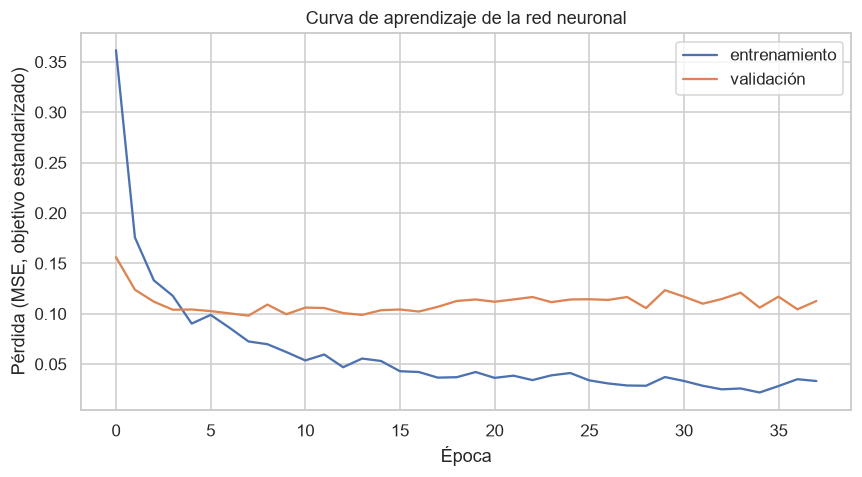

Épocas efectivas: 38 (detención temprana)
Red neuronal (MLP)     RMSE =    27,236.3 | MAE =   17,732.8 | R² = 0.8857


{'modelo': 'Red neuronal (MLP)',
 'RMSE': 27236.305717472387,
 'MAE': 17732.795989857008,
 'R2': 0.8856892424371261,
 'notas': '128-64 ReLU, dropout 0.2, Adam 1e-3'}

In [80]:
# Red neuronal multicapa con Keras
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # silencia los mensajes informativos
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")  # reproducibilidad numérica

import keras

keras.utils.set_random_seed(RANDOM_STATE)

# Objetivo: logaritmo estandarizado (estadísticos calculados solo con entrenamiento)
y_train_log = np.log1p(y_train.to_numpy())
media_log, desv_log = y_train_log.mean(), y_train_log.std()
y_train_z = (y_train_log - media_log) / desv_log
a_dolares = lambda z: np.expm1(z * desv_log + media_log)

red = keras.Sequential([
    keras.layers.Input(shape=(Xtr_esc.shape[1],)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(1),
], name="MLP_regresion")
red.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
red.summary()

parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=30, restore_best_weights=True)
historia = red.fit(Xtr_esc, y_train_z, validation_split=0.2, epochs=300,
                   batch_size=32, callbacks=[parada], verbose=0)

plt.figure(figsize=(8, 4.5))
plt.plot(historia.history["loss"], label="entrenamiento")
plt.plot(historia.history["val_loss"], label="validación")
plt.xlabel("Época"); plt.ylabel("Pérdida (MSE, objetivo estandarizado)")
plt.title("Curva de aprendizaje de la red neuronal")
plt.legend(); plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "3_curva_aprendizaje_mlp.png", bbox_inches="tight")
plt.show()

pred_mlp = a_dolares(red.predict(Xte_esc, verbose=0).ravel())
print(f"Épocas efectivas: {len(historia.history['loss'])} (detención temprana)")
evaluar_regresion("Red neuronal (MLP)", y_test, pred_mlp,
                  "128-64 ReLU, dropout 0.2, Adam 1e-3")

### 3.4 Comparación de la capacidad predictiva

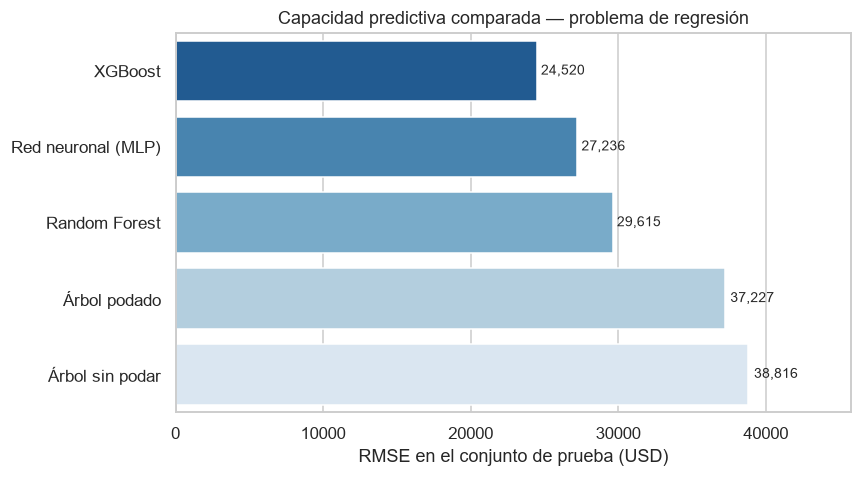

,modelo,RMSE,MAE,R2,RMSE_%_del_precio_medio,notas
0,Árbol sin podar,38816.5,26432.4,0.7678,21.3,"profundidad 25, 1133 hojas"
1,Árbol podado,37226.8,25804.7,0.7864,20.5,"ccp_alpha 4,901,416, 70 hojas"
2,Random Forest,29615.4,18807.7,0.8648,16.3,"500 árboles, mtry por defecto"
3,XGBoost,24519.7,15461.4,0.9074,13.5,"lr 0.05, profundidad 4, 339 árboles"
4,Red neuronal (MLP),27236.3,17732.8,0.8857,15.0,"128-64 ReLU, dropout 0.2, Adam 1e-3"


In [81]:
# Comparación de la capacidad predictiva
tabla_reg = pd.DataFrame(resultados_regresion)
tabla_reg["RMSE_%_del_precio_medio"] = (100 * tabla_reg["RMSE"] / y_test.mean()).round(1)
tabla_reg_fmt = tabla_reg.copy()
tabla_reg_fmt["RMSE"] = tabla_reg_fmt["RMSE"].round(1)
tabla_reg_fmt["MAE"] = tabla_reg_fmt["MAE"].round(1)
tabla_reg_fmt["R2"] = tabla_reg_fmt["R2"].round(4)
tabla_reg_fmt.to_csv(RUTA_SALIDAS / "3_comparacion_regresion.csv", index=False)

plt.figure(figsize=(8, 4.5))
orden = tabla_reg.sort_values("RMSE")
sns.barplot(data=orden, x="RMSE", y="modelo", hue="modelo", palette="Blues_r", legend=False)
for i, (_, fila) in enumerate(orden.iterrows()):
    plt.text(fila["RMSE"] * 1.01, i, f"{fila['RMSE']:,.0f}", va="center", fontsize=9)
plt.xlabel("RMSE en el conjunto de prueba (USD)"); plt.ylabel("")
plt.title("Capacidad predictiva comparada — problema de regresión")
plt.xlim(0, orden["RMSE"].max() * 1.18)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "3_comparacion_regresion.png", bbox_inches="tight")
plt.show()

tabla_reg_fmt[["modelo", "RMSE", "MAE", "R2", "RMSE_%_del_precio_medio", "notas"]]

Los datos presentados en el documento con las instrucciones de la actividad reporta un RMSE de 41.002,2 para el árbol sin podar, 42.927,25 para el árbol podado y 27.588,9 para el random forest, obtenidos en R. Los valores propios no reproducen esas cifras porque cambian la implementación, la semilla y el preprocesamiento, pero sí debe reproducirse la conclusión: el ensamble mejora de forma sustancial al árbol individual.

In [82]:
# Comparación con las cifras del enunciado del curso (R)
referencia = pd.DataFrame({
    "modelo": ["Árbol sin podar", "Árbol podado", "Random Forest"],
    "RMSE_enunciado_R": [41002.20, 42927.25, 27588.90],
})
contraste = referencia.merge(tabla_reg[["modelo", "RMSE"]], on="modelo", how="left")
contraste = contraste.rename(columns={"RMSE": "RMSE_propio_Python"})
contraste["diferencia_%"] = (100 * (contraste["RMSE_propio_Python"] - contraste["RMSE_enunciado_R"])
                             / contraste["RMSE_enunciado_R"]).round(1)
contraste = contraste.round(1)
contraste.to_csv(RUTA_SALIDAS / "3_contraste_enunciado.csv", index=False)

mejora = 100 * (1 - tabla_reg.loc[tabla_reg.modelo == "Random Forest", "RMSE"].iloc[0] /
                tabla_reg.loc[tabla_reg.modelo == "Árbol sin podar", "RMSE"].iloc[0])
mejora_ref = 100 * (1 - 27588.90 / 41002.20)
print(f"Mejora del random forest sobre el árbol — enunciado (R): {mejora_ref:.1f} %")
print(f"Mejora del random forest sobre el árbol — este trabajo  : {mejora:.1f} %")
contraste

Mejora del random forest sobre el árbol — enunciado (R): 32.7 %
Mejora del random forest sobre el árbol — este trabajo  : 23.7 %


,modelo,RMSE_enunciado_R,RMSE_propio_Python,diferencia_%
0,Árbol sin podar,41002.2,38816.5,-5.3
1,Árbol podado,42927.2,37226.8,-13.3
2,Random Forest,27588.9,29615.4,7.3


---
## 4. Problema de clasificación (Criterio 4)
---

In [83]:
# Función común de evaluación para clasificación
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix)

ETIQUETAS = ["grupo1", "grupo2", "grupo3"]
resultados_clasificacion = []
matrices_confusion = {}

def evaluar_clasificacion(nombre, y_verdadero, y_predicho, notas=""):
    """Calcula la matriz de confusión, la exactitud global, la balanceada y la de cada grupo."""
    mc = confusion_matrix(y_verdadero, y_predicho, labels=ETIQUETAS)
    por_grupo = np.divide(mc.diagonal(), mc.sum(axis=1),
                          out=np.zeros(len(ETIQUETAS)), where=mc.sum(axis=1) > 0)
    fila = {
        "modelo": nombre,
        "exactitud_global": accuracy_score(y_verdadero, y_predicho),
        "exactitud_balanceada": balanced_accuracy_score(y_verdadero, y_predicho),
        "grupo1": por_grupo[0], "grupo2": por_grupo[1], "grupo3": por_grupo[2],
        "notas": notas,
    }
    resultados_clasificacion.append(fila)
    matrices_confusion[nombre] = mc
    print(f"{nombre:<28} global {fila['exactitud_global']:.3f} | balanceada {fila['exactitud_balanceada']:.3f} "
          f"| g1 {por_grupo[0]:.3f} g2 {por_grupo[1]:.3f} g3 {por_grupo[2]:.3f}")
    return mc

def dibujar_matriz(mc, titulo, ax=None):
    ax = ax or plt.gca()
    sns.heatmap(mc, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=ETIQUETAS, yticklabels=ETIQUETAS, ax=ax)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real"); ax.set_title(titulo, fontsize=10)

print("Distribución real en el conjunto de prueba:",
      g_test.value_counts().sort_index().to_dict())

Distribución real en el conjunto de prueba: {'grupo1': 25, 'grupo2': 265, 'grupo3': 2}


### 4.1 Exactitud global y exactitud por grupo

#### 4.1.1 Árbol de decisión

Se entrenan dos versiones: la estándar y otra con `class_weight="balanced"`, que pondera cada clase de forma inversa a su frecuencia. Esta segunda versión responde a la pregunta del enunciado sobre qué hacer con el grupo 3.

In [84]:
# Árbol de decisión de clasificación
from sklearn.tree import DecisionTreeClassifier

arbol_clf = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xtr_arb, g_train)
mc_arbol = evaluar_clasificacion("Árbol de decisión", g_test, arbol_clf.predict(Xte_arb))

arbol_clf_bal = DecisionTreeClassifier(random_state=RANDOM_STATE,
                                       class_weight="balanced").fit(Xtr_arb, g_train)
evaluar_clasificacion("Árbol (class_weight)", g_test, arbol_clf_bal.predict(Xte_arb),
                      "class_weight='balanced'")

print("\nMatriz de confusión del árbol estándar:")
print(pd.DataFrame(mc_arbol, index=[f"real {e}" for e in ETIQUETAS],
                   columns=[f"pred {e}" for e in ETIQUETAS]))

Árbol de decisión            global 0.921 | balanceada 0.580 | g1 0.800 g2 0.940 g3 0.000
Árbol (class_weight)         global 0.925 | balanceada 0.698 | g1 0.640 g2 0.955 g3 0.500

Matriz de confusión del árbol estándar:
             pred grupo1  pred grupo2  pred grupo3
real grupo1           20            5            0
real grupo2           16          249            0
real grupo3            0            2            0


#### 4.1.2 Random forest

In [85]:
# Random Forest de clasificación
from sklearn.ensemble import RandomForestClassifier

bosque_clf = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE,
                                    n_jobs=-1).fit(Xtr_arb, g_train)
mc_bosque = evaluar_clasificacion("Random Forest", g_test, bosque_clf.predict(Xte_arb),
                                  "500 árboles")

bosque_clf_bal = RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1,
                                        class_weight="balanced_subsample").fit(Xtr_arb, g_train)
evaluar_clasificacion("Random Forest (class_weight)", g_test, bosque_clf_bal.predict(Xte_arb),
                      "class_weight='balanced_subsample'")

print("\nMatriz de confusión del random forest:")
print(pd.DataFrame(mc_bosque, index=[f"real {e}" for e in ETIQUETAS],
                   columns=[f"pred {e}" for e in ETIQUETAS]))

Random Forest                global 0.935 | balanceada 0.476 | g1 0.440 g2 0.989 g3 0.000
Random Forest (class_weight) global 0.942 | balanceada 0.479 | g1 0.440 g2 0.996 g3 0.000

Matriz de confusión del random forest:
             pred grupo1  pred grupo2  pred grupo3
real grupo1           11           14            0
real grupo2            3          262            0
real grupo3            0            2            0


#### 4.1.3 Gradient boosting con XGBoost

XGBoost requiere las clases codificadas como enteros. El desbalance se compensa con `sample_weight`, que es el equivalente de `class_weight` en esta librería.

In [86]:
# XGBoost de clasificación
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

codificador = LabelEncoder().fit(ETIQUETAS)
pesos = compute_sample_weight(class_weight="balanced", y=g_train)

xgb_clf = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8,
                            random_state=RANDOM_STATE, n_jobs=-1)
xgb_clf.fit(Xtr_arb, codificador.transform(g_train), sample_weight=pesos)

pred_xgb_clf = codificador.inverse_transform(xgb_clf.predict(Xte_arb))
evaluar_clasificacion("XGBoost", g_test, pred_xgb_clf, "sample_weight balanceado")

XGBoost                      global 0.952 | balanceada 0.579 | g1 0.760 g2 0.977 g3 0.000


array([[ 19,   6,   0],
       [  6, 259,   0],
       [  0,   2,   0]])

#### 4.1.4 Máquinas de vector soporte

SVM se entrena sobre la matriz escalada y codificada en *one-hot*, porque el algoritmo mide distancias en el espacio de predictores. El kernel lineal busca hiperplanos separadores en el espacio original; el kernel RBF permite fronteras curvas.

In [87]:
# SVM con kernel lineal y kernel RBF
from sklearn.svm import SVC

for nucleo in ["linear", "rbf"]:
    svm = SVC(kernel=nucleo, C=1.0, class_weight="balanced",
              random_state=RANDOM_STATE).fit(Xtr_esc, g_train)
    evaluar_clasificacion(f"SVM {nucleo}", g_test, svm.predict(Xte_esc),
                          "C=1, class_weight='balanced'")

SVM linear                   global 0.918 | balanceada 0.768 | g1 0.880 g2 0.925 g3 0.500
SVM rbf                      global 0.928 | balanceada 0.619 | g1 0.920 g2 0.936 g3 0.000


#### 4.1.5 Comparación de los clasificadores

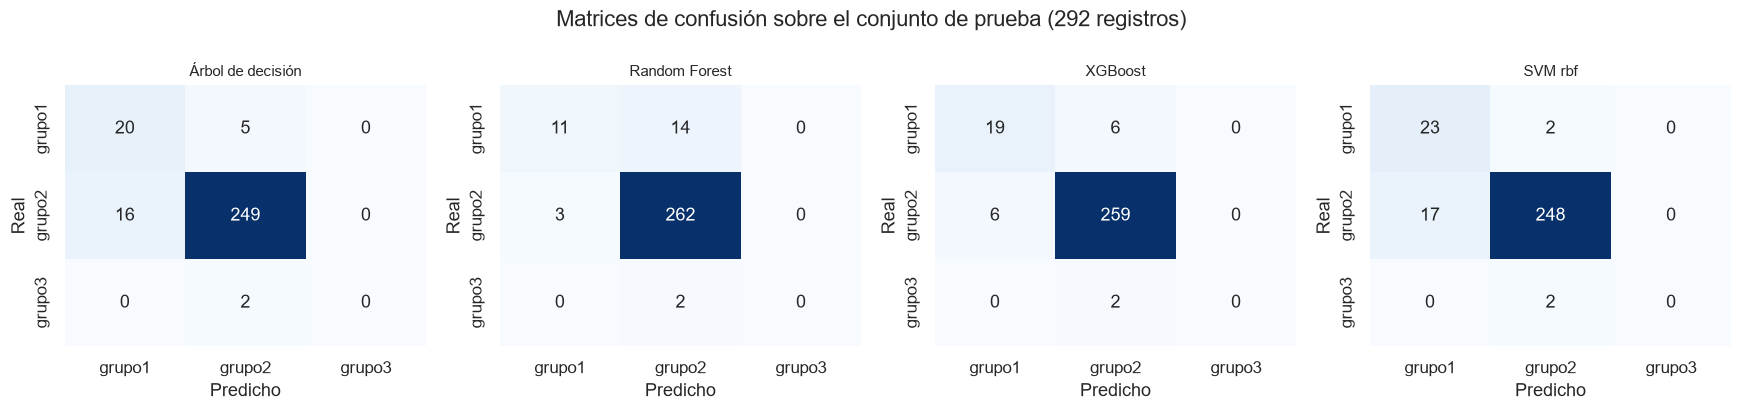

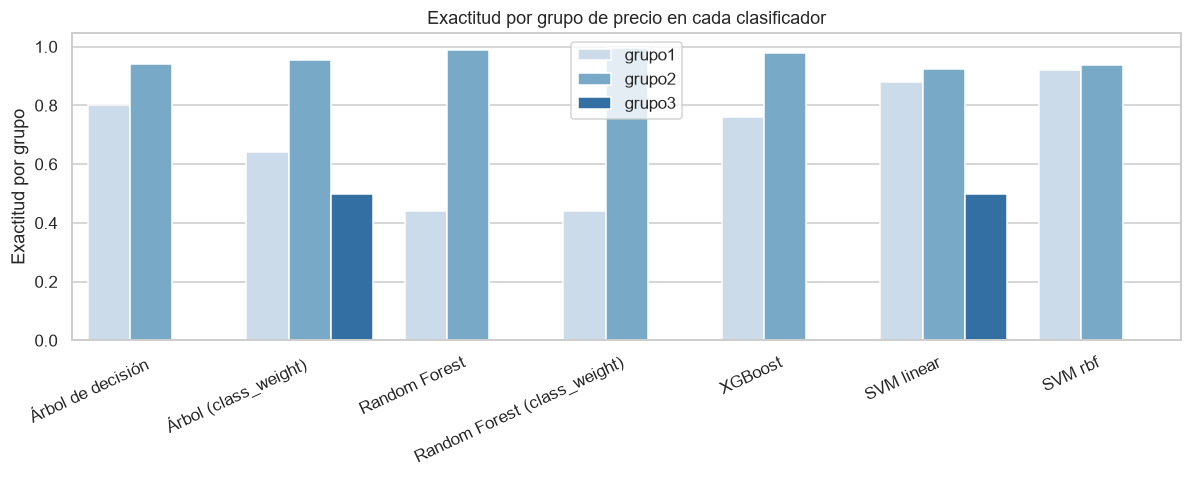

,modelo,exactitud_global,exactitud_balanceada,grupo1,grupo2,grupo3,notas
0,Árbol de decisión,0.921,0.580,0.80,0.940,0.0,
1,Árbol (class_weight),0.925,0.698,0.64,0.955,0.5,class_weight='balanced'
2,Random Forest,0.935,0.476,0.44,0.989,0.0,500 árboles
3,Random Forest (class_weight),0.942,0.479,0.44,0.996,0.0,class_weight='balanced_subsample'
4,XGBoost,0.952,0.579,0.76,0.977,0.0,sample_weight balanceado
5,SVM linear,0.918,0.768,0.88,0.925,0.5,"C=1, class_weight='balanced'"
6,SVM rbf,0.928,0.619,0.92,0.936,0.0,"C=1, class_weight='balanced'"


In [88]:
# Tabla comparativa y matrices de confusión
tabla_clf = pd.DataFrame(resultados_clasificacion)
tabla_clf.round(4).to_csv(RUTA_SALIDAS / "4_comparacion_clasificacion.csv", index=False)

principales = ["Árbol de decisión", "Random Forest", "XGBoost", "SVM rbf"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
for ax, nombre in zip(axes, principales):
    dibujar_matriz(matrices_confusion[nombre], nombre, ax=ax)
plt.suptitle("Matrices de confusión sobre el conjunto de prueba (292 registros)")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "4_matrices_confusion.png", bbox_inches="tight")
plt.show()

largo = tabla_clf.melt(id_vars="modelo", value_vars=["grupo1", "grupo2", "grupo3"],
                       var_name="grupo", value_name="exactitud")
plt.figure(figsize=(11, 4.5))
sns.barplot(data=largo, x="modelo", y="exactitud", hue="grupo", palette="Blues")
plt.xticks(rotation=25, ha="right"); plt.ylabel("Exactitud por grupo"); plt.xlabel("")
plt.title("Exactitud por grupo de precio en cada clasificador")
plt.legend(title="")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "4_exactitud_por_grupo.png", bbox_inches="tight")
plt.show()

tabla_clf.round(3)

### 4.2 Efecto del parámetro de margen C

`C` regula el equilibrio entre un margen amplio y la tolerancia a errores. Un `C` bajo admite más violaciones del margen a cambio de una frontera más suave; un `C` alto exige clasificar bien casi todo el entrenamiento y puede sobreajustar.

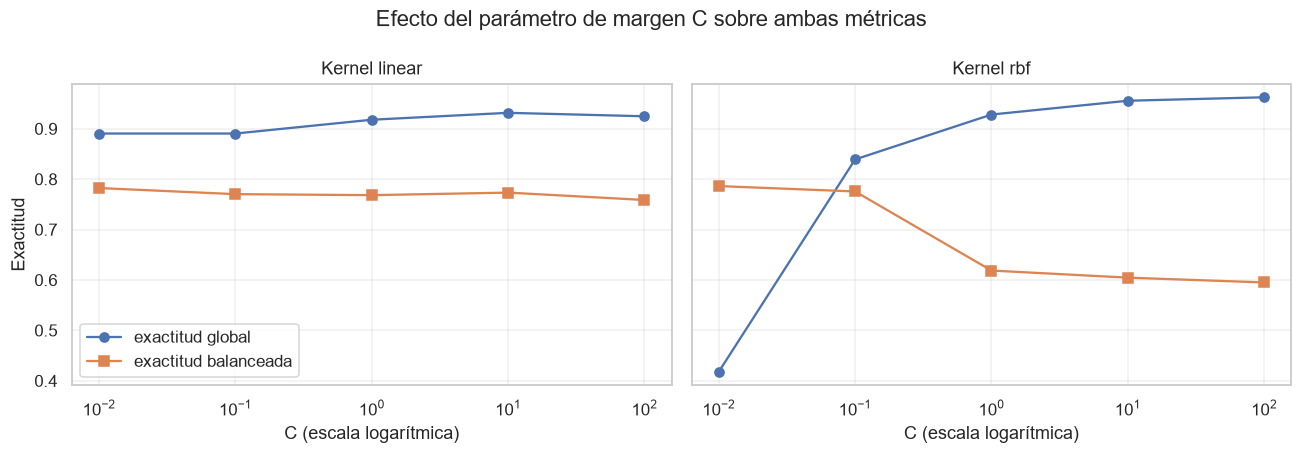

,kernel,C,exactitud_global,exactitud_balanceada,grupo3
0,linear,0.01,0.890,0.782,0.5
1,linear,0.10,0.890,0.770,0.5
2,linear,1.00,0.918,0.768,0.5
3,linear,10.00,0.932,0.773,0.5
4,linear,100.00,0.925,0.759,0.5
5,rbf,0.01,0.418,0.786,1.0
6,rbf,0.10,0.839,0.775,0.5
7,rbf,1.00,0.928,0.619,0.0
8,rbf,10.00,0.955,0.605,0.0
9,rbf,100.00,0.962,0.595,0.0


In [89]:
# Barrido del parámetro C para ambos kernels
valores_C = [0.01, 0.1, 1, 10, 100]
barrido = []
for nucleo in ["linear", "rbf"]:
    for C in valores_C:
        svm = SVC(kernel=nucleo, C=C, class_weight="balanced",
                  random_state=RANDOM_STATE).fit(Xtr_esc, g_train)
        pred = svm.predict(Xte_esc)
        mc = confusion_matrix(g_test, pred, labels=ETIQUETAS)
        pg = np.divide(mc.diagonal(), mc.sum(axis=1), out=np.zeros(3), where=mc.sum(axis=1) > 0)
        barrido.append({"kernel": nucleo, "C": C,
                        "exactitud_global": accuracy_score(g_test, pred),
                        "exactitud_balanceada": balanced_accuracy_score(g_test, pred),
                        "grupo3": pg[2]})

barrido = pd.DataFrame(barrido)
barrido.to_csv(RUTA_SALIDAS / "4_barrido_C.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, nucleo in zip(axes, ["linear", "rbf"]):
    sub = barrido[barrido.kernel == nucleo]
    ax.plot(sub["C"], sub["exactitud_global"], marker="o", label="exactitud global")
    ax.plot(sub["C"], sub["exactitud_balanceada"], marker="s", label="exactitud balanceada")
    ax.set_xscale("log"); ax.set_xlabel("C (escala logarítmica)")
    ax.set_title(f"Kernel {nucleo}"); ax.grid(alpha=.3)
axes[0].set_ylabel("Exactitud"); axes[0].legend()
plt.suptitle("Efecto del parámetro de margen C sobre ambas métricas")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "4_efecto_C.png", bbox_inches="tight")
plt.show()

barrido.round(3)

### 4.4 Contraste con las matrices del enunciado

El enunciado reporta una exactitud por grupo de 44 % / 96,2 % / 0 % con árbol de decisión y de 54,2 % / 99,6 % / 50 % con random forest sobre los mismos 292 registros de prueba.

In [90]:
# Comparación con las cifras de referencia
referencia_clf = pd.DataFrame({
    "modelo": ["Árbol de decisión", "Random Forest"],
    "g1_enunciado": [0.440, 0.542],
    "g2_enunciado": [0.962, 0.996],
    "g3_enunciado": [0.000, 0.500],
})
propio = tabla_clf[tabla_clf.modelo.isin(["Árbol de decisión", "Random Forest"])][
    ["modelo", "grupo1", "grupo2", "grupo3"]]
contraste_clf = referencia_clf.merge(propio, on="modelo").rename(
    columns={"grupo1": "g1_propio", "grupo2": "g2_propio", "grupo3": "g3_propio"})
contraste_clf.to_csv(RUTA_SALIDAS / "4_contraste_enunciado.csv", index=False)
contraste_clf.round(3)

,modelo,g1_enunciado,g2_enunciado,g3_enunciado,g1_propio,g2_propio,g3_propio
0,Árbol de decisión,0.440,0.962,0.0,0.80,0.940,0.0
1,Random Forest,0.542,0.996,0.5,0.44,0.989,0.0


---
## 5. Agrupamiento para segmentación (Criterio 5)
---

In [91]:
# Matriz para el agrupamiento
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

col_cluster = [c for c in df_limpio.select_dtypes(include=[np.number]).columns
               if c not in (COL_ID, COL_OBJETIVO)]
Z = StandardScaler().fit_transform(
    SimpleImputer(strategy="median").fit_transform(df_limpio[col_cluster]))
print(f"Matriz de agrupamiento: {Z.shape} ({len(col_cluster)} variables numéricas, sin SalePrice)")

Matriz de agrupamiento: (1460, 36) (36 variables numéricas, sin SalePrice)


### 5.1 Número de grupos: método del codo e índice de silueta

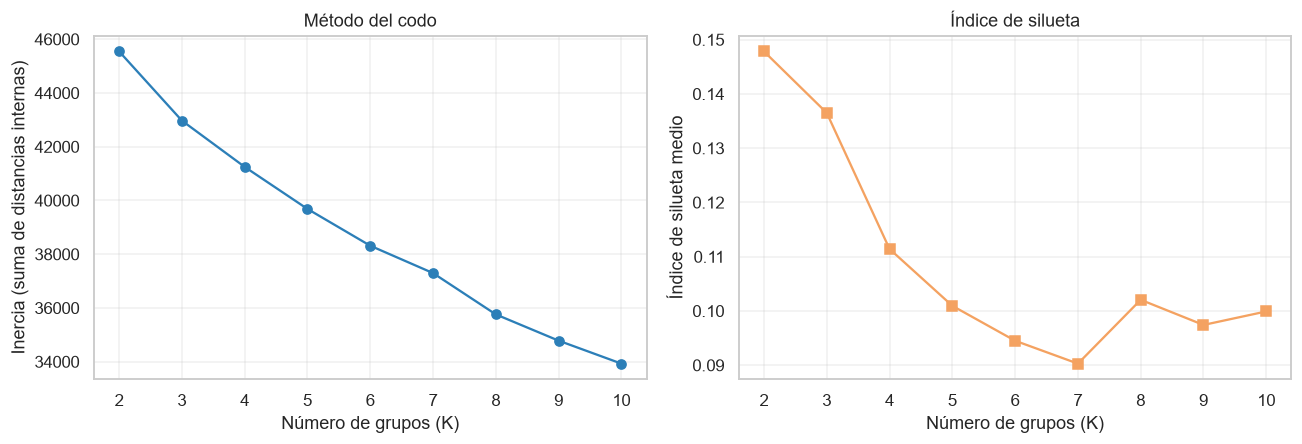

,K,inercia,silueta
0,2,45546.0,0.148
1,3,42970.0,0.136
2,4,41248.0,0.111
3,5,39683.0,0.101
4,6,38314.0,0.095
5,7,37295.0,0.090
6,8,35758.0,0.102
7,9,34781.0,0.097
8,10,33926.0,0.100


In [92]:
# Número de grupos: método del codo e índice de silueta
rango_k = range(2, 11)
inercias, siluetas = [], []
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Z)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(Z, km.labels_, sample_size=1000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].plot(list(rango_k), inercias, marker="o", color="#2c7fb8")
axes[0].set_xlabel("Número de grupos (K)"); axes[0].set_ylabel("Inercia (suma de distancias internas)")
axes[0].set_title("Método del codo")
axes[1].plot(list(rango_k), siluetas, marker="s", color="#f4a261")
axes[1].set_xlabel("Número de grupos (K)"); axes[1].set_ylabel("Índice de silueta medio")
axes[1].set_title("Índice de silueta")
for ax in axes: ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "5_codo_silueta.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"K": list(rango_k), "inercia": np.round(inercias, 0), "silueta": np.round(siluetas, 3)})

El índice de silueta es máximo en K = 2 y se mantiene por debajo de 0,15 en todos los casos, lo que indica una estructura de grupos débil: las viviendas forman un continuo antes que conglomerados separados. Se adopta K = 3 para poder contrastar los grupos con los tres rangos de precio, y esa elección se declara como decisión de diseño.

### 5.2 Perfil de los grupos obtenidos

In [93]:
# K-means con K = 3 y perfil de cada grupo
K_ELEGIDO = 3
kmeans = KMeans(n_clusters=K_ELEGIDO, random_state=RANDOM_STATE, n_init=10).fit(Z)
df_limpio["cluster_kmeans"] = kmeans.labels_

variables_perfil = ["OverallQual", "GrLivArea", "TotalBsmtSF", "GarageCars",
                    "YearBuilt", "LotArea", "TotRmsAbvGrd", COL_OBJETIVO]
perfil = df_limpio.groupby("cluster_kmeans")[variables_perfil].mean().round(1)
perfil.insert(0, "n", df_limpio["cluster_kmeans"].value_counts().sort_index())
perfil.to_csv(RUTA_SALIDAS / "5_perfiles_kmeans.csv")
perfil

,n,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,LotArea,TotRmsAbvGrd,SalePrice
cluster_kmeans,,,,,,,,,
0,394,6.9,2009.0,964.1,2.2,1986.1,11110.5,7.9,226959.9
1,369,7.1,1623.4,1549.6,2.3,1992.8,13276.8,6.6,232224.0
2,697,5.1,1179.4,849.6,1.3,1951.5,8720.1,5.7,127736.1


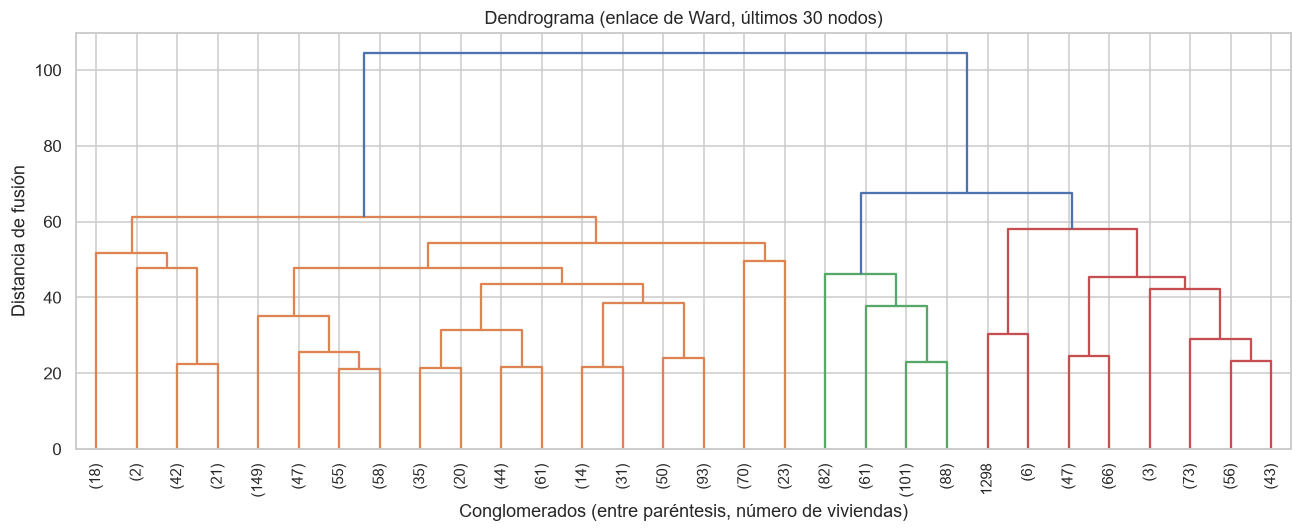

Tamaño de los grupos jerárquicos: {1: 833, 2: 332, 3: 295}


In [94]:
# Clustering jerárquico y dendrograma
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

enlace = linkage(Z, method="ward")
df_limpio["cluster_jerarquico"] = fcluster(enlace, t=K_ELEGIDO, criterion="maxclust")

plt.figure(figsize=(12, 5))
dendrogram(enlace, truncate_mode="lastp", p=30, show_leaf_counts=True,
           leaf_rotation=90, color_threshold=enlace[-(K_ELEGIDO - 1), 2])
plt.title("Dendrograma (enlace de Ward, últimos 30 nodos)")
plt.xlabel("Conglomerados (entre paréntesis, número de viviendas)")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "5_dendrograma.png", bbox_inches="tight")
plt.show()

print("Tamaño de los grupos jerárquicos:",
      df_limpio["cluster_jerarquico"].value_counts().sort_index().to_dict())

### 5.3 Correspondencia con los rangos de precio

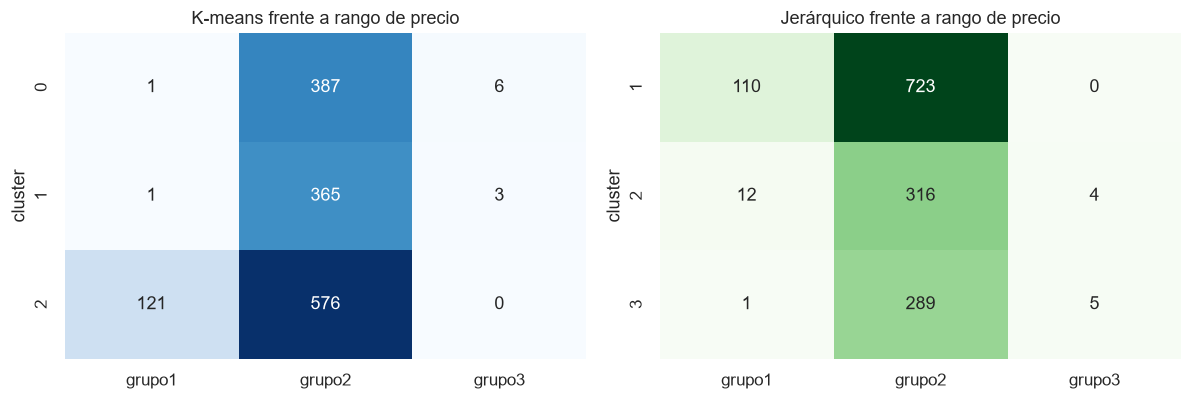

Tabla de contingencia K-means / rango de precio:


grupo,grupo1,grupo2,grupo3
cluster_kmeans,,,
0,1,387,6
1,1,365,3
2,121,576,0


In [95]:
# ¿Coinciden los grupos con los rangos de precio?
cont_km = pd.crosstab(df_limpio["cluster_kmeans"], df_limpio["grupo"])
cont_jer = pd.crosstab(df_limpio["cluster_jerarquico"], df_limpio["grupo"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sns.heatmap(cont_km, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("K-means frente a rango de precio"); axes[0].set_xlabel(""); axes[0].set_ylabel("cluster")
sns.heatmap(cont_jer, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("Jerárquico frente a rango de precio"); axes[1].set_xlabel(""); axes[1].set_ylabel("cluster")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "5_contingencia_clusters.png", bbox_inches="tight")
plt.show()

print("Tabla de contingencia K-means / rango de precio:")
cont_km

---
## 6. Detección de anomalías (Criterio 6)
---

### 6.1 Aplicación del modelo e identificación de atipicas

In [96]:
# Isolation Forest sobre las variables numéricas
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=300, contamination=0.02,
                      random_state=RANDOM_STATE, n_jobs=-1).fit(Z)
df_limpio["es_atipica"] = iso.predict(Z) == -1
df_limpio["score_anomalia"] = iso.decision_function(Z)

print(f"Viviendas marcadas como atípicas: {df_limpio['es_atipica'].sum()} de {len(df_limpio)}")
comparacion = df_limpio.groupby("es_atipica")[
    [COL_OBJETIVO, "GrLivArea", "LotArea", "OverallQual", "TotalBsmtSF"]].mean().round(0)
comparacion.index = ["Normales", "Atípicas"]
comparacion

Viviendas marcadas como atípicas: 30 de 1460


,SalePrice,GrLivArea,LotArea,OverallQual,TotalBsmtSF
Normales,177732.0,1487.0,10066.0,6.0,1042.0
Atípicas,332952.0,2849.0,32028.0,7.0,1784.0


In [97]:
# Viviendas atípicas destacadas
atipicas = df_limpio[df_limpio["es_atipica"]].nsmallest(12, "score_anomalia")
columnas_ver = [COL_ID, COL_OBJETIVO, "grupo", "GrLivArea", "LotArea", "OverallQual",
                "PoolArea", "YearBuilt", "score_anomalia"]
atipicas[columnas_ver].round(3).to_csv(RUTA_SALIDAS / "6_viviendas_atipicas.csv", index=False)

tasa_g3 = df_limpio[df_limpio["grupo"] == "grupo3"]["es_atipica"].mean()
print(f"Viviendas del grupo3 (precio >= 500.001) marcadas como atípicas: {100*tasa_g3:.1f} %")
print(f"Viviendas del grupo2 marcadas como atípicas: "
      f"{100*df_limpio[df_limpio['grupo']=='grupo2']['es_atipica'].mean():.1f} %\n")
atipicas[columnas_ver]

Viviendas del grupo3 (precio >= 500.001) marcadas como atípicas: 77.8 %
Viviendas del grupo2 marcadas como atípicas: 1.7 %



,Id,SalePrice,grupo,GrLivArea,LotArea,OverallQual,PoolArea,YearBuilt,score_anomalia
1298,1299,160000,grupo2,5642,63887,10,480,2008,-0.127368
691,692,755000,grupo3,4316,21535,10,0,1994,-0.095295
197,198,235000,grupo2,3112,25419,8,512,1918,-0.088981
185,186,475000,grupo2,3608,22950,10,0,1892,-0.087962
523,524,184750,grupo2,4676,40094,10,0,2007,-0.083679
635,636,200000,grupo2,3395,10896,6,0,1914,-0.064941
1386,1387,250000,grupo2,2784,16692,7,519,1978,-0.051139
1328,1329,256000,grupo2,2792,10440,6,0,1920,-0.044881
769,770,538000,grupo3,3279,53504,8,0,2003,-0.042556
921,922,145900,grupo2,2200,8777,5,0,1900,-0.039048


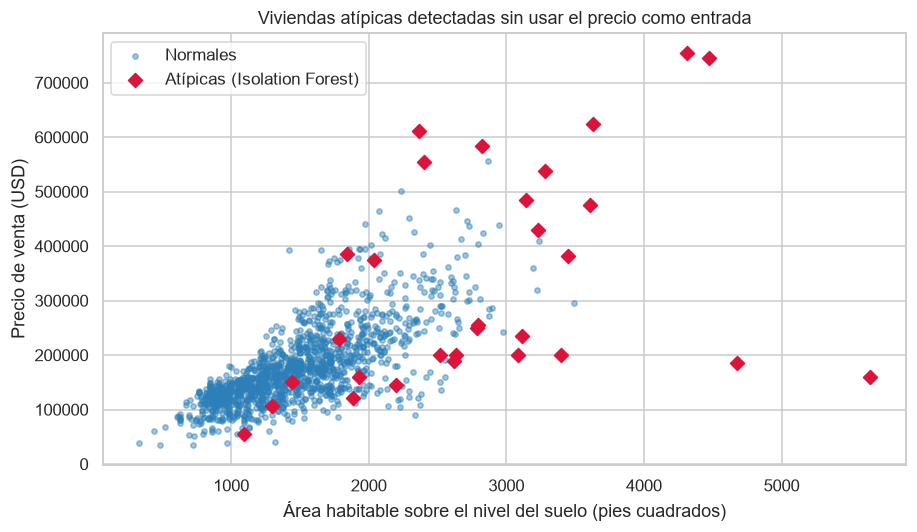

In [98]:
# Visualización de las anomalías
plt.figure(figsize=(8.5, 5))
normales = df_limpio[~df_limpio["es_atipica"]]
raras = df_limpio[df_limpio["es_atipica"]]
plt.scatter(normales["GrLivArea"], normales[COL_OBJETIVO], s=12, alpha=.45,
            color="#2c7fb8", label="Normales")
plt.scatter(raras["GrLivArea"], raras[COL_OBJETIVO], s=42, color="crimson",
            marker="D", label="Atípicas (Isolation Forest)")
plt.xlabel("Área habitable sobre el nivel del suelo (pies cuadrados)")
plt.ylabel("Precio de venta (USD)")
plt.title("Viviendas atípicas detectadas sin usar el precio como entrada")
plt.legend(); plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "6_anomalias.png", bbox_inches="tight")
plt.show()

---
## 7. Aprendizaje por refuerzo (Criterio 7)
---

Se utiliza el entorno `FrozenLake-v1` de Gymnasium en su versión determinista, una cuadrícula de 4×4 donde el agente debe llegar desde la casilla inicial hasta la meta evitando los agujeros.

| Elemento | Definición en este entorno |
|---|---|
| Estado | Casilla ocupada por el agente, de 0 a 15 |
| Acción | Mover izquierda, abajo, derecha o arriba |
| Recompensa | 1 al alcanzar la meta; 0 en cualquier otra transición |
| Política | Regla que asigna una acción a cada estado |
| Función Q | Tabla de 16×4 con la recompensa futura estimada de cada acción en cada estado |

La recompensa es escasa, ya que el agente solo recibe señal al llegar a la meta. Por eso la exploración es necesaria, y se implementa con una estrategia ε-greedy cuyo ε decae de forma exponencial.


### 7.1 Entrenamiento del agente

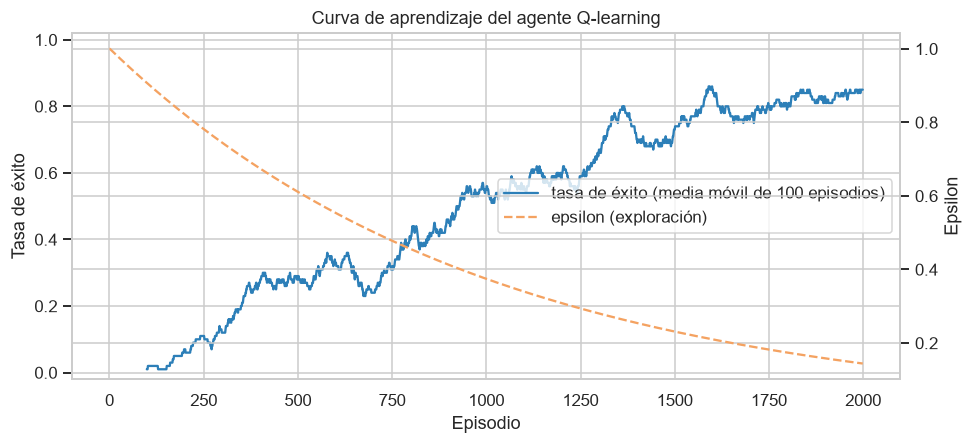

Tasa de éxito en los últimos 100 episodios de entrenamiento: 0.85 (incluye exploración residual)


In [99]:
# Entrenamiento de un agente con Q-learning
import gymnasium as gym

entorno = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
n_estados, n_acciones = entorno.observation_space.n, entorno.action_space.n

ALFA, GAMMA = 0.8, 0.95          # tasa de aprendizaje y factor de descuento
EPS_MIN, DECAIMIENTO = 0.01, 0.001
EPISODIOS = 2000

generador = np.random.default_rng(RANDOM_STATE)
Q = np.zeros((n_estados, n_acciones))
recompensas, epsilones = [], []
epsilon = 1.0

for episodio in range(EPISODIOS):
    estado, _ = entorno.reset(seed=int(RANDOM_STATE + episodio))
    terminado = truncado = False
    acumulada = 0.0
    while not (terminado or truncado):
        if generador.random() < epsilon:
            accion = entorno.action_space.sample()          # exploración
        else:
            accion = int(np.argmax(Q[estado]))              # explotación
        siguiente, recompensa, terminado, truncado, _ = entorno.step(accion)
        # Ecuación de actualización de Q-learning (Watkins y Dayan, 1992)
        Q[estado, accion] += ALFA * (recompensa
                                     + GAMMA * np.max(Q[siguiente]) * (not terminado)
                                     - Q[estado, accion])
        estado = siguiente
        acumulada += recompensa
    recompensas.append(acumulada)
    epsilones.append(epsilon)
    epsilon = max(EPS_MIN, EPS_MIN + (1.0 - EPS_MIN) * np.exp(-DECAIMIENTO * episodio))

media_movil = pd.Series(recompensas).rolling(100).mean()
fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.plot(media_movil, color="#2c7fb8", label="tasa de éxito (media móvil de 100 episodios)")
ax1.set_xlabel("Episodio"); ax1.set_ylabel("Tasa de éxito"); ax1.set_ylim(-0.02, 1.02)
ax2 = ax1.twinx()
ax2.plot(epsilones, color="#f4a261", ls="--", label="epsilon (exploración)")
ax2.set_ylabel("Epsilon")
lineas = ax1.get_lines() + ax2.get_lines()
ax1.legend(lineas, [l.get_label() for l in lineas], loc="center right")
plt.title("Curva de aprendizaje del agente Q-learning")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS / "7_curva_qlearning.png", bbox_inches="tight")
plt.show()

print(f"Tasa de éxito en los últimos 100 episodios de entrenamiento: "
      f"{np.mean(recompensas[-100:]):.2f} (incluye exploración residual)")

Política aprendida:

In [100]:
# Política aprendida y evaluación sin exploración
FLECHAS = {0: "←", 1: "↓", 2: "→", 3: "↑"}
MAPA = ["SFFF", "FHFH", "FFFH", "HFFG"]   # S inicio, F hielo, H agujero, G meta

print("Política aprendida (H = agujero, G = meta):\n")
for i in range(4):
    fila = ""
    for j in range(4):
        celda = MAPA[i][j]
        fila += f"  {celda}  " if celda in "HG" else f"  {FLECHAS[int(np.argmax(Q[i*4 + j]))]}  "
    print(fila)

exitos = 0
for episodio in range(100):
    estado, _ = entorno.reset(seed=10_000 + episodio)
    terminado = truncado = False
    while not (terminado or truncado):
        estado, recompensa, terminado, truncado, _ = entorno.step(int(np.argmax(Q[estado])))
    exitos += int(recompensa)
entorno.close()

print(f"\nÉxito de la política greedy en 100 episodios de evaluación: {exitos}/100")
print("\nValor máximo de Q por estado (recompensa futura esperada):")
print(np.round(Q.max(axis=1).reshape(4, 4), 3))

Política aprendida (H = agujero, G = meta):

  ↓    →    ↓    ←  
  ↓    H    ↓    H  
  →    ↓    ↓    H  
  H    →    →    G  

Éxito de la política greedy en 100 episodios de evaluación: 100/100

Valor máximo de Q por estado (recompensa futura esperada):
[[0.774 0.815 0.857 0.815]
 [0.815 0.    0.902 0.   ]
 [0.857 0.902 0.95  0.   ]
 [0.    0.95  1.    0.   ]]


---
## 8. Comentarios sobre los resultados (Criterio 8)
---

### 8.1 Tabla consolidada

In [101]:
# Tabla consolidada de todos los modelos
consolidado_reg = tabla_reg[["modelo", "RMSE", "MAE", "R2"]].copy()
consolidado_reg.insert(0, "problema", "Regresión")
consolidado_clf = tabla_clf[["modelo", "exactitud_global", "exactitud_balanceada",
                             "grupo1", "grupo2", "grupo3"]].copy()
consolidado_clf.insert(0, "problema", "Clasificación")

consolidado_reg.round(4).to_csv(RUTA_SALIDAS / "8_consolidado_regresion.csv", index=False)
consolidado_clf.round(4).to_csv(RUTA_SALIDAS / "8_consolidado_clasificacion.csv", index=False)

print("REGRESIÓN (menor RMSE es mejor)")
print(consolidado_reg.sort_values("RMSE").round(2).to_string(index=False))
print("\nCLASIFICACIÓN (ordenado por exactitud balanceada)")
print(consolidado_clf.sort_values("exactitud_balanceada", ascending=False).round(3).to_string(index=False))

REGRESIÓN (menor RMSE es mejor)
 problema             modelo     RMSE      MAE   R2
Regresión            XGBoost 24519.65 15461.35 0.91
Regresión Red neuronal (MLP) 27236.31 17732.80 0.89
Regresión      Random Forest 29615.42 18807.70 0.86
Regresión       Árbol podado 37226.78 25804.74 0.79
Regresión    Árbol sin podar 38816.46 26432.42 0.77

CLASIFICACIÓN (ordenado por exactitud balanceada)
     problema                       modelo  exactitud_global  exactitud_balanceada  grupo1  grupo2  grupo3
Clasificación                   SVM linear             0.918                 0.768    0.88   0.925     0.5
Clasificación         Árbol (class_weight)             0.925                 0.698    0.64   0.955     0.5
Clasificación                      SVM rbf             0.928                 0.619    0.92   0.936     0.0
Clasificación            Árbol de decisión             0.921                 0.580    0.80   0.940     0.0
Clasificación                      XGBoost             0.952          